In [2]:
print("testsing")
import glob

testsing


# Summary
This is a summary of what we have until now: 
- Retrieval models — recall, MRR, H@K across models, encoders, datasets
- Pairwise LLMs — F1/P/R + ranking metrics showing threshold is the bottleneck
- Listwise pipeline — full sweep showing LLM ranking quality is the ceiling, weights barely matter
- Key finding — retriever quality → LLM ranking quality → threshold, in that order of importance

In [6]:
import json, glob, sys
from pathlib import Path
import pandas as pd
from tqdm import tqdm

sys.path.insert(0, str(Path("..").resolve()))

from ontomap.postprocess.process import eval_preprocess_ir_outputs
from ontomap.evaluation.metrics import evaluation_report

BASE = Path("/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM")
OUTPUTS = BASE / "experiments/outputs/bio-ml/ncit-doid.disease"
DATASET = BASE / "datasets/bio-ml/ncit-doid.disease/om.json"
BASELINE_CSV = BASE / "experiments/results/rag-hybrid-model-results.csv"

with open(DATASET) as f:
    ds = json.load(f)

reference_full = ds["reference"]["equiv"]["full"]
print(f"Reference pairs: {len(reference_full):,}")

Reference pairs: 4,686


# Models table display function

In [2]:
def extract_results_from_file_pattern(file_pattern, metrics=["precision", "recall", "f-score"], datasets=["ncit-doid.disease", "omim-ordo.disease", "snomed-fma.body", "snomed-ncit.neoplas", "snomed-ncit.pharm"]):
    rows = []
    files = sorted(glob.glob(file_pattern), key=lambda f: Path(f).stat().st_mtime)
    print(f'Found {len(files)} files.')
    for f in files:
        with open(f) as fp:
            d = json.load(fp)
        if (d.get('dataset-info', {}).get('ontology-name') not in datasets):
            continue
        row = {
            'model': d.get('model'),
            'task': d.get('dataset-info', {}).get('ontology-name'),
            'encoder': d.get('encoder-id'),
        }
        evaluation_results = d.get('evaluation-results')
        if evaluation_results is not None:
            r = evaluation_results.get('full')
            for metric in metrics: 
                row[metric] = round(r.get(metric), 2)
        else:
            for metric in metrics:
                row[metric] = 'N/A'
        rows.append(row)
    pd.set_option('display.max_colwidth', None)
    df = pd.DataFrame(rows)
    df = df.drop_duplicates(subset=['model', 'task', 'encoder'], keep='last')
    df2 = df.set_index(['model', 'task', 'encoder'])
    df3 = df2.unstack(['task', 'encoder'])
    df3 = df3.reorder_levels(['task', 'encoder', None], axis=1).sort_index(axis=1)
    return df3

# Experiment 1: Embedding Models
**Important note:** N/A means that results are evaluate, just need to be evaluated. NaN means the models still have to be run. 

*notes:*
- Qwen embedding 0.6 B has to be re-run from snomed.body-fma label encoding onwards.
- QWEN embeddung 0.6B and 4B omim-ordo.disease label-children OOM error
- Models still to be run completely: 
    - Embedding gemma 300M
    - NV-embed (mid-tier)
    - gemini embedding 001

In [4]:
retriever_results = extract_results_from_file_pattern('outputs/bio-ml/*/*retrieval*.json', metrics=["recall"])
# print(retriever_results)

print(retriever_results.to_latex(index=True, float_format="%.2f", caption="Retrieval results", label="tab:retrieval"))


Found 109 files.
\begin{table}
\caption{Retrieval results}
\label{tab:retrieval}
\begin{tabular}{llllllllllllllll}
\toprule
task & \multicolumn{3}{r}{ncit-doid.disease} & \multicolumn{3}{r}{omim-ordo.disease} & \multicolumn{3}{r}{snomed-fma.body} & \multicolumn{3}{r}{snomed-ncit.neoplas} & \multicolumn{3}{r}{snomed-ncit.pharm} \\
encoder & label & label-children & label-parent & label & label-children & label-parent & label & label-children & label-parent & label & label-children & label-parent & label & label-children & label-parent \\
 & recall & recall & recall & recall & recall & recall & recall & recall & recall & recall & recall & recall & recall & recall & recall \\
model &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
BERTRetrieval & 90.25 & 77.40 & 85.51 & 71.49 & 66.62 & 70.33 & 74.67 & 49.10 & 63.45 & 79.65 & 74.71 & 73.05 & 92.87 & 90.09 & 77.80 \\
EmbeddingGemma300MRetrieval & 90.10 & 74.90 & 83.38 & 69.34 & 68.10 & 67.11 & 68.52 & 60.02 & 60.58 & 74.40 & 70.16 & 

# Experiment 2: Large language models evaluation

*notes*:
- models still to be run completely: 
    - Gemma 2 2B
    - the instruction variants

In [ ]:
pd.set_option('display.max_columns', None   )
extract_results_from_file_pattern('outputs/bio-ml/*/rag-*BertRAG*.json', datasets=["ncit-doid.disease", "omim-ordo.disease"])


Found 80 files.


task                  ncit-doid.disease                                  \
encoder                           label                  label-children   
                                f-score precision recall        f-score   
model                                                                     
FalconBertRAG                     81.66     93.92  72.24          81.59   
Gemma2_9BBertRAG                  80.77     94.95  70.27          40.86   
Gemma4_26B_A4BBertRAG             81.44     94.30  71.66          79.04   
LLaMA3BertRAG                     81.68     93.90  72.28          81.65   
LLaMA7BBertRAG                    81.68     93.90  72.28          81.54   
MistralBertRAG                    80.90     94.32  70.83          73.35   
MistralNemoBertRAG                81.68     93.90  72.28          81.69   
Qwen25BertRAG                     81.68     93.90  72.28          81.66   
Qwen25_3BBertRAG                  81.68     93.90  72.28          81.64   
Qwen35_9BBertRAG                  81.68     93.90  72.28          81.67   
VicunaBertRAG                     75.79     91.62  64.62          80.10   

task                                                                  \
encoder                                label-parent                    
                      precision recall      f-score precision recall   
model                                                                  
FalconBertRAG             93.84  72.17        81.61     93.89  72.17   
Gemma2_9BBertRAG          93.23  26.16        77.81     95.64  65.58   
Gemma4_26B_A4BBertRAG     94.13  68.12        68.75     92.53  54.69   
LLaMA3BertRAG             93.90  72.24        81.68     93.90  72.28   
LLaMA7BBertRAG            93.83  72.09        81.68     93.90  72.28   
MistralBertRAG            94.36  59.99        78.68     94.77  67.26   
MistralNemoBertRAG        93.93  72.28        81.68     93.90  72.28   
Qwen25BertRAG             93.92  72.24        81.68     93.90  72.28   
Qwen25_3BBertRAG          93.90  72.22        81.68     93.90  72.28   
Qwen35_9BBertRAG          93.90  72.26        81.68     93.90  72.28   
VicunaBertRAG             93.61  70.00        79.68     93.53  69.40   

task                  omim-ordo.disease                                  \
encoder                           label                  label-children   
                                f-score precision recall        f-score   
model                                                                     
FalconBertRAG                     58.30     88.79  43.40          58.27   
Gemma2_9BBertRAG                  54.00     89.17  38.73          14.04   
Gemma4_26B_A4BBertRAG             58.29     88.83  43.38          58.10   
LLaMA3BertRAG                     58.30     88.79  43.40          58.24   
LLaMA7BBertRAG                    58.30     88.79  43.40          58.15   
MistralBertRAG                    57.84     88.91  42.86          48.28   
MistralNemoBertRAG                  NaN       NaN    NaN            NaN   
Qwen25BertRAG                       NaN       NaN    NaN            NaN   
Qwen25_3BBertRAG                    NaN       NaN    NaN            NaN   
Qwen35_9BBertRAG                  58.30     88.79  43.40          58.23   
VicunaBertRAG                     54.54     87.14  39.69          56.26   

task                                                                  
encoder                                label-parent                   
                      precision recall      f-score precision recall  
model                                                                 
FalconBertRAG             88.73  43.38        58.30     88.79  43.40  
Gemma2_9BBertRAG          84.07   7.66        51.69     89.88  36.28  
Gemma4_26B_A4BBertRAG     89.20  43.08        57.41     89.09  42.35  
LLaMA3BertRAG             88.72  43.35        58.30     88.79  43.40  
LLaMA7BBertRAG            88.66  43.27        58.30     88.79  43.40  
MistralBertRAG            83

In [24]:
extract_results_from_file_pattern('outputs/bio-ml/*/listwise-[!r]*BertRAG*.json', datasets=["ncit-doid.disease", "omim-ordo.disease"])


Found 18 files.


task                     ncit-doid.disease                                  \
encoder                              label                  label-children   
                                   f-score precision recall        f-score   
model                                                                        
Gemma4ListwiseBertRAG                72.77     92.64  59.92          72.96   
LLaMA3ListwiseBertRAG                46.87     88.61  31.86          34.05   
Qwen35_9BListwiseBertRAG             75.82     93.49  63.76          72.63   

task                                                                     \
encoder                                   label-parent                    
                         precision recall      f-score precision recall   
model                                                                     
Gemma4ListwiseBertRAG        93.08  59.99        73.58     93.17  60.80   
LLaMA3ListwiseBertRAG        82.91  21.43        20.98     73.75  12.23   
Qwen35_9BListwiseBertRAG     93.63  59.33        72.75     93.50  59.54   

task                     omim-ordo.disease                                  \
encoder                              label                  label-children   
                                   f-score precision recall        f-score   
model                                                                        
Gemma4ListwiseBertRAG                52.69     84.42   38.3          52.79   
LLaMA3ListwiseBertRAG                29.25     79.95   17.9          19.97   
Qwen35_9BListwiseBertRAG             52.04     84.48   37.6          52.19   

task                                                                     
encoder                                   label-parent                   
                         precision recall      f-score precision recall  
model                                                                    
Gemma4ListwiseBertRAG        84.18  38.46        54.00     85.78  39.40  
LLaMA3ListwiseBertRAG        75.75  11.50        15.07     66.67   8.49  
Qwen35_9BListwiseBertRAG     84.63  37.73        47.46     86.26  32.73

In [27]:
df_no_abs = extract_results_from_file_pattern(
    'outputs/bio-ml/*/archive/listwise-Gemma4ListwiseBertRAG*2026.05.11*.json',
    datasets=["ncit-doid.disease", "omim-ordo.disease"]
)

df_with_abs = extract_results_from_file_pattern(
    'outputs/bio-ml/*/listwise-Gemma4ListwiseBertRAG*.json',
    datasets=["ncit-doid.disease", "omim-ordo.disease"]
)

df_comparison = pd.concat(
    [df_no_abs.rename(index={"Gemma4ListwiseBertRAG": "Gemma4 (no abstention)"}),
     df_with_abs.rename(index={"Gemma4ListwiseBertRAG": "Gemma4 (with abstention)"})],
)
df_comparison


Found 6 files.
Found 6 files.


task                     ncit-doid.disease                                  \
encoder                              label                  label-children   
                                   f-score precision recall        f-score   
model                                                                        
Gemma4 (no abstention)               68.55     91.92  54.65          68.69   
Gemma4 (with abstention)             72.77     92.64  59.92          72.96   

task                                                                     \
encoder                                   label-parent                    
                         precision recall      f-score precision recall   
model                                                                     
Gemma4 (no abstention)       92.07  54.78        69.03     91.91  55.27   
Gemma4 (with abstention)     93.08  59.99        73.58     93.17  60.80   

task                     omim-ordo.disease                                  \
encoder                              label                  label-children   
                                   f-score precision recall        f-score   
model                                                                        
Gemma4 (no abstention)               51.01     83.26  36.76          51.50   
Gemma4 (with abstention)             52.69     84.42  38.30          52.79   

task                                                                     
encoder                                   label-parent                   
                         precision recall      f-score precision recall  
model                                                                    
Gemma4 (no abstention)       83.53  37.22        51.98     84.61  37.52  
Gemma4 (with abstention)     84.18  38.46        54.00     85.78  39.40

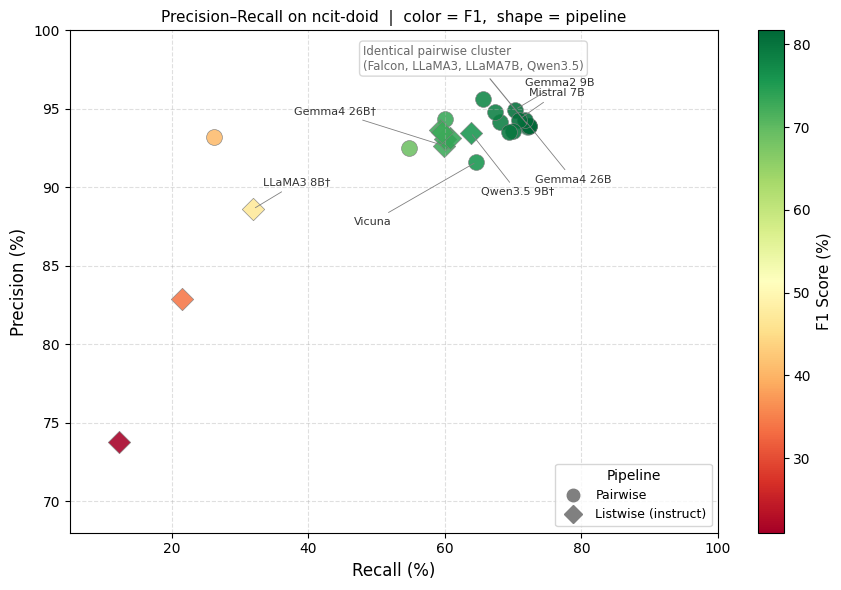

In [26]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import numpy as np

data = [
    # (model, encoder, precision, recall, f1, pipeline)
    # Pairwise — identical cluster
    ("Falcon",      "C",  93.92, 72.24, 81.66, "pairwise"),
    ("Falcon",      "CC", 93.84, 72.17, 81.59, "pairwise"),
    ("Falcon",      "CP", 93.89, 72.17, 81.61, "pairwise"),
    ("LLaMA3 8B",   "C",  93.90, 72.28, 81.68, "pairwise"),
    ("LLaMA3 8B",   "CC", 93.90, 72.24, 81.65, "pairwise"),
    ("LLaMA3 8B",   "CP", 93.90, 72.28, 81.68, "pairwise"),
    ("LLaMA7B",     "C",  93.90, 72.28, 81.68, "pairwise"),
    ("LLaMA7B",     "CC", 93.83, 72.09, 81.54, "pairwise"),
    ("LLaMA7B",     "CP", 93.90, 72.28, 81.68, "pairwise"),
    ("Qwen3.5 9B",  "C",  93.90, 72.28, 81.68, "pairwise"),
    ("Qwen3.5 9B",  "CC", 93.90, 72.26, 81.67, "pairwise"),
    ("Qwen3.5 9B",  "CP", 93.90, 72.28, 81.68, "pairwise"),
    # Pairwise — outliers
    ("Gemma2 9B",   "C",  94.95, 70.27, 80.77, "pairwise"),
    ("Gemma2 9B",   "CC", 93.23, 26.16, 40.86, "pairwise"),
    ("Gemma2 9B",   "CP", 95.64, 65.58, 77.81, "pairwise"),
    ("Gemma4 26B",  "C",  94.30, 71.66, 81.44, "pairwise"),
    ("Gemma4 26B",  "CC", 94.13, 68.12, 79.04, "pairwise"),
    ("Gemma4 26B",  "CP", 92.53, 54.69, 68.75, "pairwise"),
    ("Mistral 7B",  "C",  94.32, 70.83, 80.90, "pairwise"),
    ("Mistral 7B",  "CC", 94.36, 59.99, 73.35, "pairwise"),
    ("Mistral 7B",  "CP", 94.77, 67.26, 78.68, "pairwise"),
    ("Vicuna",      "C",  91.62, 64.62, 75.79, "pairwise"),
    ("Vicuna",      "CC", 93.61, 70.00, 80.10, "pairwise"),
    ("Vicuna",      "CP", 93.53, 69.40, 79.68, "pairwise"),
    # Listwise
    ("Gemma4 26B†", "C",  92.64, 59.92, 72.77, "listwise"),
    ("Gemma4 26B†", "CC", 93.08, 59.99, 72.96, "listwise"),
    ("Gemma4 26B†", "CP", 93.17, 60.80, 73.58, "listwise"),
    ("LLaMA3 8B†",  "C",  88.61, 31.86, 46.87, "listwise"),
    ("LLaMA3 8B†",  "CC", 82.91, 21.43, 34.05, "listwise"),
    ("LLaMA3 8B†",  "CP", 73.75, 12.23, 20.98, "listwise"),
    ("Qwen3.5 9B†", "C",  93.49, 63.76, 75.82, "listwise"),
    ("Qwen3.5 9B†", "CC", 93.63, 59.33, 72.63, "listwise"),
    ("Qwen3.5 9B†", "CP", 93.50, 59.54, 72.75, "listwise"),
]

cluster_models = {"Falcon", "LLaMA3 8B", "LLaMA7B", "Qwen3.5 9B"}

f1_all = np.array([d[4] for d in data])
norm   = mcolors.Normalize(vmin=f1_all.min(), vmax=f1_all.max())
cmap   = cm.RdYlGn
marker_map = {"pairwise": "o", "listwise": "D"}

fig, ax = plt.subplots(figsize=(9, 6))

for model, enc, prec, rec, f1, pipe in data:
    is_cluster = model in cluster_models
    ax.scatter(rec, prec,
               s=130,
               c=[cmap(norm(f1))],
               marker=marker_map[pipe],
               alpha=0.35 if is_cluster else 0.88,
               edgecolors="gray",
               linewidths=0.5)

# Cluster annotation
ax.annotate(
    "Identical pairwise cluster\n(Falcon, LLaMA3, LLaMA7B, Qwen3.5)",
    xy=(72.28, 93.90), xytext=(48, 97.5),
    fontsize=8.5, color="dimgray",
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.8),
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="lightgray", alpha=0.9)
)

# Label each non-cluster model once (at C encoder position)
labels_C = {
    "Gemma2 9B":   (94.95, 70.27, ( 1.5,  1.5)),
    "Gemma4 26B":  (94.30, 71.66, ( 1.5, -4.0)),
    "Mistral 7B":  (94.32, 70.83, ( 1.5,  1.5)),
    "Vicuna":      (91.62, 64.62, (-18,  -4.0)),
    "Gemma4 26B†": (92.64, 59.92, (-22,   2.0)),
    "LLaMA3 8B†":  (88.61, 31.86, ( 1.5,  1.5)),
    "Qwen3.5 9B†": (93.49, 63.76, ( 1.5, -4.0)),
}
for model, (prec, rec, (dx, dy)) in labels_C.items():
    ax.annotate(model, xy=(rec, prec),
                xytext=(rec + dx, prec + dy),
                fontsize=8, color="#333333",
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.6))

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("F1 Score (%)", fontsize=11)

# Legend
legend_handles = [
    mlines.Line2D([], [], color="gray", marker="o", linestyle="None",
                  markersize=9, label="Pairwise"),
    mlines.Line2D([], [], color="gray", marker="D", linestyle="None",
                  markersize=9, label="Listwise (instruct)"),
]
ax.legend(handles=legend_handles, loc="lower right", title="Pipeline", fontsize=9)

ax.set_xlabel("Recall (%)", fontsize=12)
ax.set_ylabel("Precision (%)", fontsize=12)
ax.set_title("Precision–Recall on ncit-doid  |  color = F1,  shape = pipeline", fontsize=11)
ax.set_xlim(5, 100)
ax.set_ylim(68, 100)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("llm_matching_ncitdoid.pdf", bbox_inches="tight")
plt.show()


# Pairwise pipeline
## threshold sweep post-processing performed for Llama 3 8B
Used to determine whether it is the post-processing that is the bottleneck


In [9]:
import sys, json, numpy as np, pandas as pd
sys.path.insert(0, '/data/leuven/385/vsc38504/thesis/llms4om/LLMs4OM')
from ontomap.postprocess.process import postprocess_hybrid
from ontomap.evaluation.metrics import evaluation_report

files = {
    ('ncit-doid', 'C'):  'outputs/bio-ml/ncit-doid.disease/rag-LLaMA3BertRAG-label-2026.04.15-16:47:03.json',
    ('ncit-doid', 'CC'): 'outputs/bio-ml/ncit-doid.disease/rag-LLaMA3BertRAG-label-children-2026.04.15-17:21:41.json',
    ('ncit-doid', 'CP'): 'outputs/bio-ml/ncit-doid.disease/rag-LLaMA3BertRAG-label-parent-2026.04.15-17:56:15.json',
    ('omim-ordo', 'C'):  'outputs/bio-ml/omim-ordo.disease/rag-LLaMA3BertRAG-label-2026.04.15-18:17:27.json',
    ('omim-ordo', 'CC'): 'outputs/bio-ml/omim-ordo.disease/rag-LLaMA3BertRAG-label-children-2026.04.15-18:38:40.json',
    ('omim-ordo', 'CP'): 'outputs/bio-ml/omim-ordo.disease/rag-LLaMA3BertRAG-label-parent-2026.04.15-18:59:52.json',
}
refs = {
    'ncit-doid': json.load(open('../datasets/bio-ml/ncit-doid.disease/om.json'))['reference']['equiv']['full'],
    'omim-ordo': json.load(open('../datasets/bio-ml/omim-ordo.disease/om.json'))['reference']['equiv']['full'],
}

thresholds = np.arange(0.70, 0.95, 0.05)
rows = []
for (dataset, enc), path in files.items():
    predicts = json.load(open(path))['generated-output']
    reference = refs[dataset]
    for th in thresholds:
        processed, _ = postprocess_hybrid(predicts, ir_score_threshold=round(th,2), llm_confidence_th=0.7)
        res = evaluation_report(processed, reference)
        rows.append({'dataset': dataset, 'encoder': enc, 'threshold': round(th,2),
                     'F1': round(res['f-score'],2), 'P': round(res['precision'],2), 'R': round(res['recall'],2)})

df_sweep = pd.DataFrame(rows)
df_sweep.pivot_table(index=['dataset','encoder'], columns='threshold', values='F1')


100%|██████████| 48240/48240 [00:05<00:00, 8911.72it/s] 


threshold           0.70   0.75   0.80   0.85   0.90
dataset   encoder                                   
ncit-doid C        78.96  80.49  81.90  82.67  81.68
          CC       78.92  80.46  81.87  82.64  81.65
          CP       78.96  80.49  81.90  82.67  81.68
omim-ordo C        59.19  61.97  63.32  62.41  58.30
          CC       59.14  61.90  63.26  62.36  58.24
          CP       59.19  61.97  63.32  62.41  58.30

## Varying IR and LLM threshold together for Llama 3 label

In [10]:
from itertools import product

llm_ths = [0.5, 0.6, 0.7, 0.8]
ir_ths = np.arange(0.70, 0.95, 0.05)

rag_file = 'outputs/bio-ml/omim-ordo.disease/rag-LLaMA3BertRAG-label-2026.04.15-18:17:27.json'
reference = json.load(open('../datasets/bio-ml/omim-ordo.disease/om.json'))['reference']['equiv']['full']
predicts = json.load(open(rag_file))['generated-output']

rows = []
for llm_th, ir_th in product(llm_ths, ir_ths):
    processed, _ = postprocess_hybrid(predicts, ir_score_threshold=round(ir_th,2), llm_confidence_th=llm_th)
    res = evaluation_report(processed, reference)
    rows.append({'llm_th': llm_th, 'ir_th': round(ir_th,2),
                 'F1': round(res['f-score'],2), 'P': round(res['precision'],2), 'R': round(res['recall'],2)})

pd.DataFrame(rows).pivot_table(index='llm_th', columns='ir_th', values='F1')


100%|██████████| 48240/48240 [00:05<00:00, 8612.61it/s] 


ir_th,0.70,0.75,0.80,0.85,0.90
llm_th,,,,,
0.5,59.19,61.97,63.32,62.41,58.3
0.6,59.19,61.97,63.32,62.41,58.3
0.7,59.19,61.97,63.32,62.41,58.3
0.8,59.19,61.97,63.32,62.41,58.3


# Listwise pipeline

## Fine-tuning of RRF k and weight values and ir threshold 

Sweeps all combinations of `ir_weight` (0.0–1.0) and `ir_score_threshold` (0.0–0.95) on the Gemma4 26B instruct listwise output for ncit-doid (label encoder). Reports F1, precision, and recall for each combination to identify the true performance bottleneck.


### Sweep function
calls postprocess_listwise + evaluation_report for each (ir_weight, threshold) pair


In [7]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM")))

from ontomap.postprocess.process import postprocess_listwise
from ontomap.evaluation.metrics import evaluation_report
import itertools

def sweep_listwise_weights(listwise_file, reference,
                           ir_weights=None, thresholds=None, k=1):
    """
    Sweep ir_weight and ir_score_threshold on a listwise pipeline output file.
    llm_weight is always set to 1 - ir_weight.
    
    Returns a DataFrame with columns:
        ir_weight, llm_weight, threshold, precision, recall, f1, n_preds
    """
    if ir_weights is None:
        ir_weights = [round(x * 0.1, 1) for x in range(0, 11)]  # 0.0 to 1.0
    if thresholds is None:
        thresholds = [round(x * 0.05, 2) for x in range(0, 20)]  # 0.0 to 0.95

    with open(listwise_file) as f:
        d = json.load(f)
    if isinstance(d, list):
        d = d[0] if d else {}
    predicts = d.get("generated-output", [])
    if len(predicts) < 2:
        raise ValueError(f"Expected generated-output with 2 entries, got {len(predicts)}")

    rows = []
    for ir_w, th in itertools.product(ir_weights, thresholds):
        llm_w = round(1.0 - ir_w, 1)
        final_predict, _ = postprocess_listwise(
            predicts, ir_weight=ir_w, llm_weight=llm_w, k=k, ir_score_threshold=th
        )
        ev = evaluation_report(predicts=final_predict, references=reference)
        rows.append({
            "ir_weight": ir_w,
            "llm_weight": llm_w,
            "threshold": th,
            "precision": round(ev["precision"], 2),
            "recall": round(ev["recall"], 2),
            "f1": round(ev["f-score"], 2),
            "n_preds": ev["predictions-len"],
        })

    df = pd.DataFrame(rows)
    return df


### Apply sweep to Gemma4 listwise output on ncit-doid (label encoder)


In [10]:
import json, pandas as pd
BASE = Path("/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM")
OUTPUTS = BASE / "experiments" / "outputs" / "bio-ml"
DATASETS = BASE / "datasets" / "bio-ml"

# Load reference for ncit-doid
with open(DATASETS / "ncit-doid.disease" / "om.json") as f:
    ref_data = json.load(f)
reference_ncit_doid = ref_data["reference"]["equiv"]["full"]

# Find label (C encoder) file only — exclude label-children and label-parent
listwise_files = sorted(
    (OUTPUTS / "ncit-doid.disease").glob("listwise-Gemma4ListwiseBertRAG-label-2*.json")
)
print("Found:", [f.name for f in listwise_files])
listwise_file = listwise_files[-1]

df_sweep = sweep_listwise_weights(listwise_file, reference_ncit_doid)
print(df_sweep.sort_values("f1", ascending=False).head(20).to_string(index=False))


Found: ['listwise-Gemma4ListwiseBertRAG-label-2026.05.16-15:15:11.json']
 ir_weight  llm_weight  threshold  precision  recall    f1  n_preds
       0.1         0.9       0.85      86.29   64.45 73.78     3500
       0.2         0.8       0.85      86.24   64.45 73.77     3502
       0.3         0.7       0.85      86.19   64.45 73.75     3504
       0.4         0.6       0.85      86.04   64.43 73.68     3509
       0.5         0.5       0.85      85.78   64.36 73.54     3516
       0.6         0.4       0.85      85.53   64.34 73.44     3525
       0.7         0.3       0.85      85.38   64.32 73.37     3530
       0.8         0.2       0.85      85.35   64.30 73.34     3530
       0.9         0.1       0.85      85.35   64.30 73.34     3530
       0.3         0.7       0.90      92.64   59.92 72.77     3031
       0.1         0.9       0.90      92.64   59.92 72.77     3031
       0.2         0.8       0.90      92.64   59.92 72.77     3031
       0.4         0.6       0.90      92.5

### Display F1, precision, recall as pivot tables (ir_weight × threshold)


In [12]:
# Pivot: rows = ir_weight, cols = threshold, values = f1
pivot_f1 = df_sweep.pivot(index="ir_weight", columns="threshold", values="f1")
print("\nF1 pivot (ir_weight × threshold):")
print(pivot_f1.to_string())

# Show best configuration
best = df_sweep.loc[df_sweep["f1"].idxmax()]
print(f"\nBest config: ir_weight={best.ir_weight}, llm_weight={best.llm_weight}, "
      f"threshold={best.threshold} → P={best.precision}, R={best.recall}, F1={best.f1}")



F1 pivot (ir_weight × threshold):
threshold   0.00   0.05   0.10   0.15   0.20   0.25   0.30   0.35   0.40   0.45   0.50   0.55   0.60   0.65   0.70   0.75   0.80   0.85   0.90   0.95
ir_weight                                                                                                                                            
0.0        59.94  59.94  59.94  59.94  59.94  59.94  59.94  59.94  59.94  59.95  60.11  60.56  61.24  62.33  63.97  65.88  67.62  68.67  67.76  63.28
0.1        66.13  66.13  66.13  66.13  66.13  66.13  66.13  66.13  66.13  66.15  66.29  66.74  67.41  68.31  69.59  71.20  72.70  73.78  72.77  68.23
0.2        66.10  66.10  66.10  66.10  66.10  66.10  66.10  66.10  66.10  66.11  66.25  66.70  67.37  68.27  69.55  71.16  72.67  73.77  72.77  68.23
0.3        66.02  66.02  66.02  66.02  66.02  66.02  66.02  66.02  66.02  66.03  66.17  66.62  67.29  68.18  69.50  71.11  72.65  73.75  72.77  68.23
0.4        65.74  65.74  65.74  65.74  65.74  65.74  65.74  65.74

In [15]:
pivot_recall = df_sweep.pivot(index="ir_weight", columns="threshold", values="recall")
print(pivot_recall.to_string())


threshold   0.00   0.05   0.10   0.15   0.20   0.25   0.30   0.35   0.40   0.45   0.50   0.55   0.60   0.65   0.70   0.75   0.80   0.85   0.90   0.95
ir_weight                                                                                                                                            
0.0        63.72  63.72  63.72  63.72  63.72  63.72  63.72  63.72  63.72  63.72  63.72  63.72  63.70  63.47  63.12  62.25  60.35  57.47  53.39  46.97
0.1        70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.72  70.47  70.08  69.21  67.41  64.45  59.92  52.60
0.2        70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.72  70.47  70.08  69.21  67.41  64.45  59.92  52.60
0.3        70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.74  70.72  70.47  70.08  69.21  67.41  64.45  59.92  52.60
0.4        70.53  70.53  70.53  70.53  70.53  70.53  70.53  70.53  70.53  70.53  70.53  70.53  70.53

## Fine-tuning the IR post-processing threshold 

In [11]:
import glob, json, sys
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))
from ontomap.postprocess.process import postprocess_listwise
from ontomap.evaluation.metrics import evaluation_report

datasets_info = {}
for task in ["ncit-doid.disease", "omim-ordo.disease"]:
    with open(f"../datasets/bio-ml/{task}/om.json") as f:
        ds = json.load(f)
    datasets_info[task] = ds["reference"]["equiv"]["full"]

thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
rows = []

for f in sorted(glob.glob("outputs/bio-ml/*/*listwise*.json")):
    with open(f) as fp:
        d = json.load(fp)
    if not isinstance(d, dict):
        continue
    task = d.get("dataset-info", {}).get("ontology-name")
    if task not in datasets_info:
        continue
    predicts_raw = d.get("generated-output")
    if predicts_raw is None:
        continue
    reference = datasets_info[task]
    for th in thresholds:
        preds, _ = postprocess_listwise(predicts_raw, ir_score_threshold=th)
        r = evaluation_report(predicts=preds, references=reference)
        rows.append({
            "task": task, "encoder": d.get("encoder-id"), "ir_th": th,
            "f-score": round(r["f-score"], 2),
            "precision": round(r["precision"], 2),
            "recall": round(r["recall"], 2),
        })

df = pd.DataFrame(rows)

for metric in ["f-score", "precision", "recall"]:
    print(f"\n=== {metric.upper()} ===")
    print(df.pivot_table(index="ir_th", columns=["task", "encoder"], values=metric).to_string())




=== F-SCORE ===
task    ncit-doid.disease                             omim-ordo.disease                            
encoder             label label-children label-parent             label label-children label-parent
ir_th                                                                                              
0.00            56.153333      52.160000    49.930000         42.980000      41.386667    38.836667
0.10            56.153333      52.160000    49.930000         42.980000      41.386667    38.836667
0.20            56.153333      52.160000    49.930000         42.980000      41.386667    38.836667
0.30            56.153333      52.160000    49.930000         42.980000      41.386667    38.836667
0.40            56.153333      52.160000    49.930000         42.980000      41.386667    38.836667
0.50            56.370000      52.333333    50.043333         43.046667      41.436667    38.883333
0.60            57.650000      53.426667    50.806667         43.743333      42.073

# MRR and Hits@K local ranking metrics


## Functions

In [1]:
def compute_ir_ranking_metrics(retrieval_file, reference, k_values=(1, 3, 5)):
    gt_map = {}
    for entry in reference:
        gt_map.setdefault(entry["source"], set()).add(entry["target"])

    with open(retrieval_file) as f:
        d = json.load(f)

    entries = d.get("generated-output", [])
    if not entries or not isinstance(entries[0], dict):
        return None

    n_total = len(entries)
    n_with_gt = 0
    mrr_sum = 0.0
    hits = {k: 0 for k in k_values}

    for entry in entries:
        source = entry["source"]
        target_cands = entry["target-cands"]
        scores = entry["score-cands"]

        all_gts = gt_map.get(source, set())
        if not all_gts:
            continue

        n_with_gt += 1
        gts_in_cands = all_gts & set(target_cands)

        if not gts_in_cands:
            continue  # contributes 0 to all metrics

        n = len(target_cands)
        order = sorted(range(n), key=lambda i: scores[i], reverse=True)
        best_rank = min(
            next(r + 1 for r, idx in enumerate(order) if target_cands[idx] == gt)
            for gt in gts_in_cands
        )

        mrr_sum += 1.0 / best_rank
        for k in k_values:
            if best_rank <= k:
                hits[k] += 1

    result = {
        "total": n_total,
        "with_gt": n_with_gt,
        "IR MRR": round(mrr_sum / n_with_gt, 4) if n_with_gt else None,
    }
    for k in k_values:
        result[f"IR H@{k}"] = round(100 * hits[k] / n_with_gt, 2) if n_with_gt else None
    return result


In [2]:
def compute_listwise_ranking_metrics(listwise_file, reference, k_values=(1, 3, 5)):
    gt_map = {}
    for entry in reference:
        gt_map.setdefault(entry["source"], set()).add(entry["target"])

    with open(listwise_file) as f:
        d = json.load(f)

    go = d.get("generated-output", [])
    if len(go) < 2:
        return None

    ir_outputs = go[0].get("ir-outputs", [])
    llm_outputs = go[1].get("llm-output", [])

    # Build LLM ranking lookup: source → sorted list of (score, target)
    from collections import defaultdict
    llm_by_source = defaultdict(list)
    for item in llm_outputs:
        llm_by_source[item["source"]].append((item["score"], item["target"]))

    n_with_gt = 0
    ir_mrr_sum = 0.0
    llm_mrr_sum = 0.0
    ir_hits = {k: 0 for k in k_values}
    llm_hits = {k: 0 for k in k_values}

    for entry in ir_outputs:
        source = entry["source"]
        target_cands = entry["target-cands"]
        scores = entry["score-cands"]

        all_gts = gt_map.get(source, set())
        if not all_gts:
            continue

        n_with_gt += 1
        gts_in_cands = all_gts & set(target_cands)
        if not gts_in_cands:
            continue

        n = len(target_cands)

        # IR rank
        ir_order = sorted(range(n), key=lambda i: scores[i], reverse=True)
        ir_best_rank = min(
            next(r + 1 for r, idx in enumerate(ir_order) if target_cands[idx] == gt)
            for gt in gts_in_cands
        )
        ir_mrr_sum += 1.0 / ir_best_rank
        for k in k_values:
            if ir_best_rank <= k:
                ir_hits[k] += 1

        # LLM rank (score ascending = better rank)
        llm_pairs = sorted(llm_by_source.get(source, []), key=lambda x: x[0])
        llm_targets_ranked = [t for _, t in llm_pairs]
        if llm_targets_ranked:
            llm_best_rank = min(
                next((r + 1 for r, t in enumerate(llm_targets_ranked) if t == gt), n + 1)
                for gt in gts_in_cands
            )
            llm_mrr_sum += 1.0 / llm_best_rank
            for k in k_values:
                if llm_best_rank <= k:
                    llm_hits[k] += 1

    result = {
        "total": len(ir_outputs),
        "with_gt": n_with_gt,
        "IR MRR": round(ir_mrr_sum / n_with_gt, 4) if n_with_gt else None,
        "LLM MRR": round(llm_mrr_sum / n_with_gt, 4) if n_with_gt else None,
    }
    for k in k_values:
        result[f"IR H@{k}"] = round(100 * ir_hits[k] / n_with_gt, 2) if n_with_gt else None
        result[f"LLM H@{k}"] = round(100 * llm_hits[k] / n_with_gt, 2) if n_with_gt else None
    return result


In [3]:
def compute_pairwise_ranking_metrics(rag_file, reference, k_values=(1, 3, 5)):
    gt_map = {}
    for entry in reference:
        gt_map.setdefault(entry["source"], set()).add(entry["target"])

    with open(rag_file) as f:
        d = json.load(f)
    if isinstance(d, list):
        d = d[0] if d else {}

    go = d.get("generated-output", [])
    if len(go) < 2:
        return None

    ir_outputs = go[0].get("ir-outputs", [])
    llm_outputs = go[1].get("llm-output", [])

    from collections import defaultdict
    llm_by_source = defaultdict(list)
    for item in llm_outputs:
        llm_by_source[item["source"]].append((item["score"], item["target"]))

    n_with_gt = 0
    ir_mrr_sum = 0.0
    llm_mrr_sum = 0.0
    ir_hits = {k: 0 for k in k_values}
    llm_hits = {k: 0 for k in k_values}

    for entry in ir_outputs:
        source = entry["source"]
        target_cands = entry["target-cands"]
        scores = entry["score-cands"]

        all_gts = gt_map.get(source, set())
        if not all_gts:
            continue

        n_with_gt += 1
        gts_in_cands = all_gts & set(target_cands)
        if not gts_in_cands:
            continue

        n = len(target_cands)

        # IR rank
        ir_order = sorted(range(n), key=lambda i: scores[i], reverse=True)
        ir_best_rank = min(
            next(r + 1 for r, idx in enumerate(ir_order) if target_cands[idx] == gt)
            for gt in gts_in_cands
        )
        ir_mrr_sum += 1.0 / ir_best_rank
        for k in k_values:
            if ir_best_rank <= k:
                ir_hits[k] += 1

        # LLM rank: sort by yes-probability descending
        llm_pairs = sorted(llm_by_source.get(source, []), key=lambda x: x[0], reverse=True)
        llm_targets_ranked = [t for _, t in llm_pairs]
        if llm_targets_ranked:
            llm_best_rank = min(
                next((r + 1 for r, t in enumerate(llm_targets_ranked) if t == gt), n + 1)
                for gt in gts_in_cands
            )
            llm_mrr_sum += 1.0 / llm_best_rank
            for k in k_values:
                if llm_best_rank <= k:
                    llm_hits[k] += 1

    result = {
        "total": len(ir_outputs),
        "with_gt": n_with_gt,
        "IR MRR": round(ir_mrr_sum / n_with_gt, 4) if n_with_gt else None,
        "LLM MRR": round(llm_mrr_sum / n_with_gt, 4) if n_with_gt else None,
    }
    for k in k_values:
        result[f"IR H@{k}"] = round(100 * ir_hits[k] / n_with_gt, 2) if n_with_gt else None
        result[f"LLM H@{k}"] = round(100 * llm_hits[k] / n_with_gt, 2) if n_with_gt else None
    return result


## Results MRR and H@K

### Retriever only results

In [4]:
import pandas as pd
import json, glob, re
from pathlib import Path

all_tasks = ["ncit-doid.disease", "omim-ordo.disease", "snomed-fma.body", "snomed-ncit.neoplas", "snomed-ncit.pharm"]
datasets_ref = {}
for task in all_tasks:
    with open(f"../datasets/bio-ml/{task}/om.json") as f:
        ds = json.load(f)
    datasets_ref[task] = ds["reference"]["equiv"]["full"]

rows = []
for f in sorted(glob.glob("outputs/bio-ml/*/retrieval-*.json")):
    task = Path(f).parent.name
    if task not in datasets_ref:
        continue

    fname = Path(f).name
    m = re.match(r"retrieval-(.+)-(label(?:-\w+)?)-\d{4}\.\d{2}\.\d{2}", fname)
    model = m.group(1) if m else fname
    encoder = m.group(2) if m else "unknown"

    metrics = compute_ir_ranking_metrics(f, datasets_ref[task])
    if metrics is None:
        continue
    metrics["model"] = model
    metrics["encoder"] = encoder
    metrics["task"] = task
    rows.append(metrics)
pd.set_option('display.max_rows', None)
df_ir = pd.DataFrame(rows).set_index(["task", "model", "encoder"])
df_ir


total  \
task                model                           encoder                 
ncit-doid.disease   BERTRetrieval                   label           15762   
                                                    label-children  15762   
                                                    label-parent    15762   
                    EmbeddingGemma300MRetrieval     label           15762   
                                                    label-children  15762   
                                                    label-parent    15762   
                    LlamaNemotronEmbeddingRetrieval label           15762   
                                                    label-children  15762   
                                                    label-parent    15762   
                    Qwen3Embedding4BRetrieval       label           15762   
                                                    label-children  15762   
                                                    label-parent    15762   
                    Qwen3EmbeddingRetrieval         label           15762   
                                                    label-children  15762   
                                                    label-parent    15762   
                    SpecterBERTRetrieval            label           15762   
                                                    label-children  15762   
                                                    label-parent    15762   
                    TFIDFRetrieval                  label           15762   
                                                    label-children  15762   
                                                    label-parent    15762   
omim-ordo.disease   BERTRetrieval                   label            9648   
                                                    label-children   9648   
                                                    label-parent     9648   
                    EmbeddingGemma300MRetrieval     label            9648   
                                                    label-children   9648   
                                                    label-parent     9648   
                    LlamaNemotronEmbeddingRetrieval label            9648   
                                                    label-children   9648   
                                                    label-parent     9648   
                    Qwen3Embedding4BRetrieval       label            9648   
                                                    label-children   9648   
                                                    label-parent     9648   
                    Qwen3EmbeddingRetrieval         label            9648   
                                                    label-children   9648   
                                                    label-parent     9648   
                    SpecterBERTRetrieval            label            9648   
                                                    label-children   9648   
                                                    label-parent     9648   
                    TFIDFRetrieval                  label            9648   
                                                    label-children   9648   
                                                    label-parent     9648   
snomed-fma.body     BERTRetrieval                   label           34418   
                                                    label-children  34418   
                                                    label-parent    34418   
                    EmbeddingGemma300MRetrieval     label           34418   
                                                    label-children  34418   
                                                    label-parent    34418   
                    LlamaNemotronEmbeddingRetrieval label           34418   
                                                    label-children  34418   
                                                    label-parent

### Listwise pipeline results (retriever + instruct LLM)

#### Key finding: Listwise recall collapse
- Gemma4 Instruct: P=91.92, R=54.65, F1=68.55 (threshold=0.9)
- Pairwise LLaMA3: P=93.9, R=72.28, F1=81.68
- Precision nearly identical → LLM is NOT the problem
- Recall gap of ~17pp → ~1700 correct matches filtered by S_sim≥0.9 threshold
- RRF re-ranks candidates with lower IR scores to rank 1; those fail the threshold
- Threshold was designed for pairwise, penalises listwise


In [32]:
rows = []
for f in sorted(glob.glob("outputs/bio-ml/*/listwise-*.json")):
    # skip rankings files
    if "listwise-rankings" in Path(f).name:
        continue

    task = Path(f).parent.name
    if task not in datasets_ref:
        continue

    fname = Path(f).name
    m = re.match(r"listwise-(.+)-(label(?:-\w+)?)-\d{4}\.\d{2}\.\d{2}", fname)
    model = m.group(1) if m else fname
    encoder = m.group(2) if m else "unknown"

    metrics = compute_listwise_ranking_metrics(f, datasets_ref[task])
    if metrics is None:
        continue
    metrics["model"] = model
    metrics["encoder"] = encoder
    metrics["task"] = task
    rows.append(metrics)

df_llm_ranking = pd.DataFrame(rows).set_index(["task", "model", "encoder"])
df_llm_ranking


total  with_gt  \
task              model                    encoder                          
ncit-doid.disease Gemma4ListwiseBertRAG    label           15762     4630   
                                           label-children  15762     4630   
                                           label-parent    15762     4630   
                  LLaMA3ListwiseBertRAG    label           15762     4630   
                                           label-children  15762     4630   
                                           label-parent    15762     4630   
                  Qwen35_9BListwiseBertRAG label           15762     4630   
                                           label-children  15762     4630   
                                           label-parent    15762     4630   
omim-ordo.disease Gemma4ListwiseBertRAG    label            9648     3699   
                                           label-children   9648     3699   
                                           label-parent     9648     3699   
                  LLaMA3ListwiseBertRAG    label            9648     3699   
                                           label-children   9648     3699   
                                           label-parent     9648     3699   
                  Qwen35_9BListwiseBertRAG label            9648     3699   
                                           label-children   9648     3699   
                                           label-parent     9648     3699   

                                                           IR MRR  LLM MRR  \
task              model                    encoder                           
ncit-doid.disease Gemma4ListwiseBertRAG    label           0.8587   0.8944   
                                           label-children  0.8587   0.8964   
                                           label-parent    0.8587   0.8933   
                  LLaMA3ListwiseBertRAG    label           0.8587   0.5923   
                                           label-children  0.8587   0.5365   
                                           label-parent    0.8587   0.4762   
                  Qwen35_9BListwiseBertRAG label           0.8587   0.8623   
                                           label-children  0.8587   0.7956   
                                           label-parent    0.8587   0.7863   
omim-ordo.disease Gemma4ListwiseBertRAG    label           0.6551   0.6767   
                                           label-children  0.6551   0.6772   
                                           label-parent    0.6551   0.6822   
                  LLaMA3ListwiseBertRAG    label           0.6551   0.4414   
                                           label-children  0.6551   0.3946   
                                           label-parent    0.6551   0.3724   
                  Qwen35_9BListwiseBertRAG label           0.6551   0.6035   
                                           label-children  0.6551   0.6013   
                                           label-parent    0.6551   0.4967   

                                                           IR H@1  LLM H@1  \
task              model                    encoder                           
ncit-doid.disease Gemma4ListwiseBertRAG    label            82.53    88.40   
                                           label-children   82.53    88.68   
                                           label-parent     82.53    88.29   
                  LLaMA3ListwiseBertRAG    label            82.53    29.87   
                                           label-children   82.53    19.78   
                                           label-parent     82.53     7.32   
                  Qwen35_9BListwiseBertRAG label            82.53    83.91   
                                           label-children   82.53    72.29   
                                           label-parent     82.53    73.69   
omim-ordo.disease Gemma4ListwiseBertRAG    label            61.34    65.13   
                     

### Pairwise pipeline (retriever + base LLM)

#### Key finding: Pairwise LLM ranking vs IR ranking
- IR MRR is identical across all models (BERT retriever uses label-only, independent of encoder)
- Most pairwise LLMs have LLM MRR < IR MRR (Falcon: 0.42, LLaMA7B: 0.37, Vicuna: 0.35)
- Only Qwen25 and Qwen35 marginally improve over IR (0.87 vs 0.86)
- Despite very different LLM MRR, all models produce identical F1 → post-processing threshold dominates


In [5]:
rows = []
for f in sorted(glob.glob("outputs/bio-ml/*/rag-*BertRAG*.json")):
    with open(f) as fp:
        d = json.load(fp)
    if isinstance(d, list):
        d = d[0] if d else {}

    dataset_info = d.get("dataset-info", {})
    if isinstance(dataset_info, list):
        dataset_info = dataset_info[0] if dataset_info else {}
    task = dataset_info.get("ontology-name")
    if task not in datasets_ref:
        continue

    fname = Path(f).name
    m = re.match(r"rag-(.+)BertRAG-(label(?:-\w+)?)-\d{4}\.\d{2}\.\d{2}", fname)
    model = m.group(1) if m else fname
    encoder = m.group(2) if m else "unknown"

    metrics = compute_pairwise_ranking_metrics(f, datasets_ref[task])
    if metrics is None:
        continue
    metrics["model"] = model
    metrics["encoder"] = encoder
    metrics["task"] = task
    rows.append(metrics)

df_pairwise_ranking = pd.DataFrame(rows).set_index(["task", "model", "encoder"])
df_pairwise_ranking


total  with_gt  IR MRR  \
task                model          encoder                                  
ncit-doid.disease   Falcon         label           15762     4630  0.8587   
                                   label-children  15762     4630  0.8587   
                                   label-parent    15762     4630  0.8587   
                    Gemma2_9B      label           15762     4630  0.8587   
                                   label-children  15762     4630  0.8587   
                                   label-parent    15762     4630  0.8587   
                    Gemma4_26B_A4B label           15762     4630  0.8587   
                                   label-children  15762     4630  0.8587   
                                   label-parent    15762     4630  0.8587   
                    LLaMA3         label           15762     4630  0.8587   
                                   label-children  15762     4630  0.8587   
                                   label-parent    15762     4630  0.8587   
                    LLaMA7B        label           15762     4630  0.8587   
                                   label-children  15762     4630  0.8587   
                                   label-parent    15762     4630  0.8587   
                    Mistral        label           15762     4630  0.8587   
                                   label-children  15762     4630  0.8587   
                                   label-parent    15762     4630  0.8587   
                    MistralNemo    label           15762     4630  0.8587   
                                   label-children  15762     4630  0.8587   
                                   label-parent    15762     4630  0.8587   
                    Qwen25         label           15762     4630  0.8587   
                                   label-children  15762     4630  0.8587   
                                   label-parent    15762     4630  0.8587   
                    Qwen25_3B      label           15762     4630  0.8587   
                                   label-children  15762     4630  0.8587   
                                   label-parent    15762     4630  0.8587   
                    Qwen35_9B      label           15762     4630  0.8587   
                                   label-children  15762     4630  0.8587   
                                   label-parent    15762     4630  0.8587   
                    Vicuna         label           15762     4630  0.8587   
                                   label-children  15762     4630  0.8587   
                                   label-parent    15762     4630  0.8587   
omim-ordo.disease   Falcon         label            9648     3699  0.6551   
                                   label-children   9648     3699  0.6551   
                                   label-parent     9648     3699  0.6551   
                    Gemma2_9B      label            9648     3699  0.6551   
                                   label-children   9648     3699  0.6551   
                                   label-parent     9648     3699  0.6551   
                    Gemma4_26B_A4B label            9648     3699  0.6551   
                                   label-children   9648     3699  0.6551   
                                   label-parent     9648     3699  0.6551   
                    LLaMA3         label            9648     3699  0.6551   
                                   label-children   9648     3699  0.6551   
                                   label-parent     9648     3699  0.6551   
                    LLaMA7B        label            9648     3699  0.6551   
                                   label-children   9648     3699  0.6551   
                                   label-parent     9648     3699  0.6551   
                    Mistral        label            9648     3699  0.6551   
                                   label-children   9648     3699  0.6551   
                                   label-parent

# Top 1 pipeline


In [8]:
import glob
files = glob.glob("/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml/*/rag-*Qwen34BRAG*.json")
print(files)



['/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml/ncit-doid.disease/rag-LLaMA3Qwen34BRAG-label-2026.03.18-13:32:15.json', '/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml/ncit-doid.disease/rag-LLaMA3Qwen34BRAG-label-children-2026.03.18-14:03:07.json', '/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml/ncit-doid.disease/rag-LLaMA3Qwen34BRAG-label-parent-2026.03.18-14:33:58.json', '/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml/ncit-doid.disease/rag-Qwen35_9BQwen34BRAG-label-2026.05.18-01:17:20.json', '/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml/ncit-doid.disease/rag-Qwen35_9BQwen34BRAG-label-children-2026.05.18-02:20:44.json', '/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml/ncit-doid.disease/rag-Qwen35_9BQwen34BRAG-label-pa

In [3]:

import json, glob, re
from pathlib import Path
import pandas as pd
import numpy as np

df_qwen34 = extract_results_from_file_pattern(
"/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml/*/rag-*Qwen34BRAG*.json")
df_qwen34


Found 18 files.


task                ncit-doid.disease                                  \
encoder                         label                  label-children   
                              f-score precision recall        f-score   
model                                                                   
LLaMA3Qwen34BRAG                85.09     89.71  80.92          85.06   
Qwen35_9BQwen34BRAG             85.08     89.69  80.92          85.07   

task                                                                \
encoder                              label-parent                    
                    precision recall      f-score precision recall   
model                                                                
LLaMA3Qwen34BRAG        89.70  80.88        85.09     89.71  80.92   
Qwen35_9BQwen34BRAG     89.69  80.90        85.08     89.69  80.92   

task                omim-ordo.disease  ... snomed-ncit.neoplas  \
encoder                         label  ...        label-parent   
                              f-score  ...              recall   
model                                  ...                       
LLaMA3Qwen34BRAG                  NaN  ...                 NaN   
Qwen35_9BQwen34BRAG             58.78  ...               46.32   

task                snomed-ncit.pharm                                  \
encoder                         label                  label-children   
                              f-score precision recall        f-score   
model                                                                   
LLaMA3Qwen34BRAG                  NaN       NaN    NaN            NaN   
Qwen35_9BQwen34BRAG             65.16     84.49  53.02          65.16   

task                                                                
encoder                              label-parent                   
                    precision recall      f-score precision recall  
model                                                               
LLaMA3Qwen34BRAG          NaN    NaN          NaN       NaN    NaN  
Qwen35_9BQwen34BRAG     84.59  52.99        65.16     84.49  53.02  

[2 rows x 45 columns]

In [4]:
pd.set_option('display.max_columns', None)
df_qwen34
df_qwen34.loc[["Qwen35_9BQwen34BRAG"], (slice(None), "label", slice(None))]


task                ncit-doid.disease                  omim-ordo.disease  \
encoder                         label                              label   
                              f-score precision recall           f-score   
model                                                                      
Qwen35_9BQwen34BRAG             85.08     89.69  80.92             58.78   

task                                 snomed-fma.body                   \
encoder                                        label                    
                    precision recall         f-score precision recall   
model                                                                   
Qwen35_9BQwen34BRAG     79.35  46.68           13.52     29.11   8.81   

task                snomed-ncit.neoplas                  snomed-ncit.pharm  \
encoder                           label                              label   
                                f-score precision recall           f-score   
model                                                                        
Qwen35_9BQwen34BRAG               53.82     64.21  46.32             65.16   

task                                  
encoder                               
                    precision recall  
model                                 
Qwen35_9BQwen34BRAG     84.49  53.02

In [14]:
import sys
sys.path.insert(0, "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM")

import itertools, glob, json
from ontomap.postprocess.process import postprocess_hybrid
from ontomap.evaluation.evaluator import evaluation_report

results = []
for task, ref in datasets_ref.items():
    files = sorted(glob.glob(
        f"/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml/{task}/rag-*Qwen34BRAG*label-*.json"
    ))
    if not files:
        continue
    m = compute_pairwise_ranking_metrics(files[-1], ref)
    m["task"] = task
    results.append(m)

pd.DataFrame(results).set_index("task")


,total,with_gt,IR MRR,LLM MRR,IR H@1,LLM H@1,IR H@3,LLM H@3,IR H@5,LLM H@5
task,,,,,,,,,,
ncit-doid.disease,15762,4630,0.8973,0.8055,86.37,70.00,92.96,91.51,94.88,94.88
omim-ordo.disease,9648,3699,0.6606,0.6151,61.34,53.64,70.24,68.96,73.40,73.40
snomed-fma.body,34418,6312,0.6748,0.6290,58.24,50.06,76.24,75.67,81.69,81.69
snomed-ncit.neoplas,22971,3450,0.8320,0.6904,78.58,54.38,87.45,84.17,90.06,90.06
snomed-ncit.pharm,29500,5652,0.8972,0.8288,84.61,72.17,94.90,94.04,95.88,95.88


In [19]:
import glob, json
import pandas as pd

f = sorted(glob.glob(
    "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml/snomed-fma.body/rag-*Qwen34BRAG*label-*.json"
))[-1]
print("File:", f)

with open(f) as fp:
    d = json.load(fp)

ir_outputs = d["generated-output"][0]["ir-outputs"]
llm_outputs = d["generated-output"][1]["llm-output"]

ir_lookup = {}
for ir in ir_outputs:
    ir_lookup[ir["source"]] = dict(zip(ir["target-cands"], ir["score-cands"]))

all_preds = [
    (p["source"], p["target"], p["score"], ir_lookup.get(p["source"], {}).get(p["target"], 0.0))
    for p in llm_outputs
]

ref_list = datasets_ref["snomed-fma.body"]
ref_dict = {r["source"]: r["target"] for r in ref_list}

rows = []
for th in [round(x * 0.05, 2) for x in range(0, 20)]:
    pred_dict = {}
    for src, tgt, llm_sc, ir_sc in all_preds:
        if ir_sc >= th and llm_sc >= 0.7:
            if src not in pred_dict or llm_sc > pred_dict[src][1]:
                pred_dict[src] = (tgt, llm_sc)

    tp = sum(1 for src, (tgt, _) in pred_dict.items() if ref_dict.get(src) == tgt)
    fp = len(pred_dict) - tp
    fn = sum(1 for src in ref_dict if pred_dict.get(src, (None,))[0] != ref_dict[src])

    p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

    rows.append({"threshold": th, "precision": round(p, 3), "recall": round(r, 3),
                 "f1": round(f1, 3), "n_preds": len(pred_dict)})

pd.DataFrame(rows).set_index("threshold")


File: /vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml/snomed-fma.body/rag-Qwen35_9BQwen34BRAG-label-parent-2026.05.18-12:36:13.json


,precision,recall,f1,n_preds
threshold,,,,
0.00,0.085,0.463,0.144,34418
0.05,0.085,0.463,0.144,34418
0.10,0.085,0.463,0.144,34418
0.15,0.085,0.463,0.144,34418
0.20,0.085,0.463,0.144,34418
0.25,0.085,0.463,0.144,34418
0.30,0.085,0.463,0.144,34418
0.35,0.085,0.463,0.144,34418
0.40,0.085,0.463,0.144,34418


In [ ]:
import sys, glob, json
import numpy as np
import pandas as pd
sys.path.insert(0, '/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM')

BASE     = '/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml'
DATA_DIR = '/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/datasets/bio-ml'

task_labels = {
    "ncit-doid.disease":   "NCIT-DOID",
    "omim-ordo.disease":   "OMIM-ORDO",
    "snomed-fma.body":     "SNOMED-FMA",
    "snomed-ncit.neoplas": "SNOMED-NCIT (N)",
    "snomed-ncit.pharm":   "SNOMED-NCIT (P)",
}

encoders = {
    "C":  "label-2",
    "CC": "label-children-2",
    "CP": "label-parent-2",
}

# Load references
datasets_ref = {}
for task in task_labels:
    with open(f"{DATA_DIR}/{task}/om.json") as fp:
        datasets_ref[task] = json.load(fp)["reference"]["equiv"]["full"]

thresholds = [round(x * 0.05, 2) for x in range(0, 20)]  # 0.00 to 0.95

rows = []
for task, label in task_labels.items():
    for enc_key, enc_pattern in encoders.items():
        files = sorted(glob.glob(f"{BASE}/{task}/rag-Qwen35_9BQwen34BRAG-{enc_pattern}*.json"))
        if not files:
            print(f"No file found for {label} / {enc_key}")
            continue
        f = files[-1]
        print(f"  {label} [{enc_key}]: {f.split('/')[-1]}")

        with open(f) as fp:
            d = json.load(fp)

        ir_outputs = d["generated-output"][0]["ir-outputs"]
        llm_outputs = d["generated-output"][1]["llm-output"]

        ir_lookup = {}
        for ir in ir_outputs:
            ir_lookup[ir["source"]] = dict(zip(ir["target-cands"], ir["score-cands"]))

        all_preds = [
            (p["source"], p["target"], p["score"],
             ir_lookup.get(p["source"], {}).get(p["target"], 0.0))
            for p in llm_outputs
        ]

        ref_dict = {r["source"]: r["target"] for r in datasets_ref[task]}

        for th in thresholds:
            pred_dict = {}
            for src, tgt, llm_sc, ir_sc in all_preds:
                if ir_sc >= th and llm_sc >= 0.7:
                    if src not in pred_dict or llm_sc > pred_dict[src][1]:
                        pred_dict[src] = (tgt, llm_sc)

            tp = sum(1 for src, (tgt, _) in pred_dict.items() if ref_dict.get(src) == tgt)
            fp = len(pred_dict) - tp
            fn = sum(1 for src in ref_dict if pred_dict.get(src, (None,))[0] != ref_dict[src])

            p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

            rows.append({
                "dataset": label, "encoder": enc_key, "threshold": th,
                "precision": round(p * 100, 2),
                "recall":    round(r * 100, 2),
                "f1":        round(f1 * 100, 2),
            })

df_sweep = pd.DataFrame(rows)

print("\n=== F1 ===")
print(df_sweep.pivot_table(index=["dataset", "encoder"], columns="threshold", values="f1").to_string())
print("\n=== Precision ===")
print(df_sweep.pivot_table(index=["dataset", "encoder"], columns="threshold", values="precision").to_string())
print("\n=== Recall ===")
print(df_sweep.pivot_table(index=["dataset", "encoder"], columns="threshold", values="recall").to_string())


  NCIT-DOID [C]: rag-Qwen35_9BQwen34BRAG-label-2026.05.18-01:17:20.json
  NCIT-DOID [CC]: rag-Qwen35_9BQwen34BRAG-label-children-2026.05.18-02:20:44.json
  NCIT-DOID [CP]: rag-Qwen35_9BQwen34BRAG-label-parent-2026.05.18-03:23:59.json
  OMIM-ORDO [C]: rag-Qwen35_9BQwen34BRAG-label-2026.05.18-04:03:10.json
  OMIM-ORDO [CC]: rag-Qwen35_9BQwen34BRAG-label-children-2026.05.18-04:42:25.json
  OMIM-ORDO [CP]: rag-Qwen35_9BQwen34BRAG-label-parent-2026.05.18-05:21:39.json
  SNOMED-FMA [C]: rag-Qwen35_9BQwen34BRAG-label-2026.05.18-07:45:55.json
  SNOMED-FMA [CC]: rag-Qwen35_9BQwen34BRAG-label-children-2026.05.18-10:11:10.json
  SNOMED-FMA [CP]: rag-Qwen35_9BQwen34BRAG-label-parent-2026.05.18-12:36:13.json
  SNOMED-NCIT (N) [C]: rag-Qwen35_9BQwen34BRAG-label-2026.05.18-14:08:38.json
  SNOMED-NCIT (N) [CC]: rag-Qwen35_9BQwen34BRAG-label-children-2026.05.18-15:41:04.json
  SNOMED-NCIT (N) [CP]: rag-Qwen35_9BQwen34BRAG-label-parent-2026.05.18-17:13:23.json
  SNOMED-NCIT (P) [C]: rag-Qwen35_9BQwen34B

In [3]:
import sys, glob, json
import pandas as pd
sys.path.insert(0, '/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM')

from ontomap.evaluation.metrics import evaluation_report

BASE     = '/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml'
DATA_DIR = '/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/datasets/bio-ml'

task_labels = {
    "ncit-doid.disease":   "NCIT-DOID",
    "omim-ordo.disease":   "OMIM-ORDO",
    "snomed-fma.body":     "SNOMED-FMA",
    "snomed-ncit.neoplas": "SNOMED-NCIT (N)",
    "snomed-ncit.pharm":   "SNOMED-NCIT (P)",
}

encoders = {
    "C":  "label-2",
    "CC": "label-children-2",
    "CP": "label-parent-2",
}

datasets_ref = {}
for task in task_labels:
    with open(f"{DATA_DIR}/{task}/om.json") as fp:
        datasets_ref[task] = json.load(fp)["reference"]["equiv"]["full"]

thresholds = [round(x * 0.05, 2) for x in range(0, 20)]  # 0.00 to 0.95

rows = []
for task, label in task_labels.items():
    for enc_key, enc_pattern in encoders.items():
        files = sorted(glob.glob(f"{BASE}/{task}/rag-Qwen35_9BQwen34BRAG-{enc_pattern}*.json"))
        if not files:
            print(f"No file found for {label} / {enc_key}")
            continue
        f = files[-1]
        print(f"  {label} [{enc_key}]: {f.split('/')[-1]}")

        with open(f) as fp:
            d = json.load(fp)

        ir_outputs = d["generated-output"][0]["ir-outputs"]
        llm_outputs = d["generated-output"][1]["llm-output"]

        ir_lookup = {}
        for ir in ir_outputs:
            ir_lookup[ir["source"]] = dict(zip(ir["target-cands"], ir["score-cands"]))

        all_preds = [
            (p["source"], p["target"], p["score"],
             ir_lookup.get(p["source"], {}).get(p["target"], 0.0))
            for p in llm_outputs
        ]

        reference = datasets_ref[task]

        for th in thresholds:
            pred_dict = {}
            for src, tgt, llm_sc, ir_sc in all_preds:
                if ir_sc >= th and llm_sc >= 0.7:
                    if src not in pred_dict or llm_sc > pred_dict[src][1]:
                        pred_dict[src] = (tgt, llm_sc)

            # Convert to pipeline format and use official evaluation_report
            predicts_list = [
                {"source": src, "target": tgt, "score": sc}
                for src, (tgt, sc) in pred_dict.items()
            ]
            res = evaluation_report(predicts_list, reference)

            rows.append({
                "dataset": label, "encoder": enc_key, "threshold": th,
                "precision": round(res["precision"], 2),
                "recall":    round(res["recall"], 2),
                "f1":        round(res["f-score"], 2),
            })

df_sweep = pd.DataFrame(rows)

print("\n=== F1 ===")
print(df_sweep.pivot_table(index=["dataset", "encoder"], columns="threshold", values="f1").to_string())
print("\n=== Precision ===")
print(df_sweep.pivot_table(index=["dataset", "encoder"], columns="threshold", values="precision").to_string())
print("\n=== Recall ===")
print(df_sweep.pivot_table(index=["dataset", "encoder"], columns="threshold", values="recall").to_string())


  NCIT-DOID [C]: rag-Qwen35_9BQwen34BRAG-label-2026.05.18-01:17:20.json
  NCIT-DOID [CC]: rag-Qwen35_9BQwen34BRAG-label-children-2026.05.18-02:20:44.json
  NCIT-DOID [CP]: rag-Qwen35_9BQwen34BRAG-label-parent-2026.05.18-03:23:59.json
  OMIM-ORDO [C]: rag-Qwen35_9BQwen34BRAG-label-2026.05.18-04:03:10.json
  OMIM-ORDO [CC]: rag-Qwen35_9BQwen34BRAG-label-children-2026.05.18-04:42:25.json
  OMIM-ORDO [CP]: rag-Qwen35_9BQwen34BRAG-label-parent-2026.05.18-05:21:39.json
  SNOMED-FMA [C]: rag-Qwen35_9BQwen34BRAG-label-2026.05.18-07:45:55.json
  SNOMED-FMA [CC]: rag-Qwen35_9BQwen34BRAG-label-children-2026.05.18-10:11:10.json
  SNOMED-FMA [CP]: rag-Qwen35_9BQwen34BRAG-label-parent-2026.05.18-12:36:13.json
  SNOMED-NCIT (N) [C]: rag-Qwen35_9BQwen34BRAG-label-2026.05.18-14:08:38.json
  SNOMED-NCIT (N) [CC]: rag-Qwen35_9BQwen34BRAG-label-children-2026.05.18-15:41:04.json
  SNOMED-NCIT (N) [CP]: rag-Qwen35_9BQwen34BRAG-label-parent-2026.05.18-17:13:23.json
  SNOMED-NCIT (P) [C]: rag-Qwen35_9BQwen34B

In [1]:
import pandas as pd

df_sweep = pd.read_csv("threshold_sweep_Qwen35_9BQwen34BRAG.csv")

print("=== F1 ===")
display(df_sweep.pivot_table(index=["dataset", "encoder"], columns="threshold", values="f1"))

print("=== Precision ===")
display(df_sweep.pivot_table(index=["dataset", "encoder"], columns="threshold", values="precision"))

print("=== Recall ===")
display(df_sweep.pivot_table(index=["dataset", "encoder"], columns="threshold", values="recall"))


=== F1 ===


threshold                 0.00   0.05   0.10   0.15   0.20   0.25   0.30  \
dataset         encoder                                                    
NCIT-DOID       C        78.58  78.58  78.58  78.58  78.58  78.58  78.58   
                CC       78.56  78.56  78.56  78.56  78.56  78.56  78.56   
                CP       78.58  78.58  78.58  78.58  78.58  78.58  78.58   
OMIM-ORDO       C        52.13  52.13  52.13  52.13  52.13  52.13  52.13   
                CC       51.99  51.99  51.99  51.99  51.99  51.99  51.99   
                CP       52.13  52.13  52.13  52.13  52.13  52.13  52.13   
SNOMED-FMA      C        18.24  18.24  18.24  18.24  18.24  18.24  18.24   
                CC       18.22  18.22  18.22  18.22  18.22  18.22  18.22   
                CP       18.24  18.24  18.24  18.24  18.24  18.24  18.24   
SNOMED-NCIT (N) C        41.39  41.39  41.39  41.39  41.39  41.39  41.39   
                CC       41.36  41.36  41.36  41.36  41.36  41.36  41.36   
                CP       41.39  41.39  41.39  41.39  41.39  41.39  41.39   
SNOMED-NCIT (P) C        51.53  51.53  51.53  51.53  51.53  51.53  51.53   
                CC       51.48  51.48  51.48  51.48  51.48  51.48  51.48   
                CP       51.53  51.53  51.53  51.53  51.53  51.53  51.53   

threshold                 0.35   0.40   0.45   0.50   0.55   0.60   0.65  \
dataset         encoder                                                    
NCIT-DOID       C        78.58  78.58  78.58  78.58  78.59  78.71  79.07   
                CC       78.56  78.56  78.56  78.56  78.57  78.69  79.04   
                CP       78.58  78.58  78.58  78.58  78.59  78.71  79.07   
OMIM-ORDO       C        52.13  52.13  52.13  52.13  52.14  52.22  52.49   
                CC       51.99  51.99  51.99  51.99  52.01  52.08  52.35   
                CP       52.13  52.13  52.13  52.13  52.14  52.22  52.49   
SNOMED-FMA      C        18.24  18.24  18.24  18.24  18.25  18.27  18.31   
                CC       18.22  18.22  18.22  18.22  18.23  18.24  18.28   
                CP       18.24  18.24  18.24  18.24  18.25  18.27  18.31   
SNOMED-NCIT (N) C        41.39  41.39  41.39  41.39  41.41  41.48  41.65   
                CC       41.36  41.36  41.36  41.37  41.39  41.46  41.63   
                CP       41.39  41.39  41.39  41.39  41.41  41.48  41.65   
SNOMED-NCIT (P) C        51.53  51.53  51.53  51.53  51.55  51.59  51.79   
                CC       51.48  51.48  51.48  51.48  51.50  51.54  51.74   
                CP       51.53  51.53  51.53  51.53  51.55  51.59  51.79   

threshold                 0.70   0.75   0.80   0.85   0.90   0.95  
dataset         encoder                                            
NCIT-DOID       C        79.78  80.61  81.71  83.56  85.08  81.13  
                CC       79.75  80.58  81.68  83.54  85.07  81.13  
                CP       79.78  80.61  81.71  83.56  85.08  81.13  
OMIM-ORDO       C        53.16  54.17  56.01  58.67  58.78  46.35  
                CC       53.03  54.03  55.87  58.52  58.66  46.32  
                CP       53.16  54.17  56.01  58.67  58.78  46.35  
SNOMED-FMA      C        18.41  18.90  20.67  22.94  13.52   0.82  
                CC       18.39  18.87  20.64  22.91  13.50   0.82  
                CP       18.41  18.90  20.67  22.94  13.52   0.82  
SNOMED-NCIT (N) C        42.04  43.11  45.24  49.28  53.82  21.68  
                CC       42.01  43.08  45.23  49.26  53.82  21.68  
                CP       42.04  43.11  45.24  49.28  53.82  21.68  
SNOMED-NCIT (P) C        52.41  54.39  59.46  64.11  65.16  30.10  
                CC       52.36  54.35  59.40  64.08  65.16  30.10  
                CP       52.41  54.39  59.46  64.11  65.16  30.10

=== Precision ===


threshold                 0.00   0.05   0.10   0.15   0.20   0.25   0.30  \
dataset         encoder                                                    
NCIT-DOID       C        74.48  74.48  74.48  74.48  74.48  74.48  74.48   
                CC       74.47  74.47  74.47  74.47  74.47  74.47  74.47   
                CP       74.48  74.48  74.48  74.48  74.48  74.48  74.48   
OMIM-ORDO       C        49.73  49.73  49.73  49.73  49.73  49.73  49.73   
                CC       49.60  49.60  49.60  49.60  49.60  49.60  49.60   
                CP       49.73  49.73  49.73  49.73  49.73  49.73  49.73   
SNOMED-FMA      C        13.00  13.00  13.00  13.00  13.00  13.00  13.00   
                CC       12.98  12.98  12.98  12.98  12.98  12.98  12.98   
                CP       13.00  13.00  13.00  13.00  13.00  13.00  13.00   
SNOMED-NCIT (N) C        33.61  33.61  33.61  33.61  33.61  33.61  33.61   
                CC       33.59  33.59  33.59  33.59  33.59  33.59  33.59   
                CP       33.61  33.61  33.61  33.61  33.61  33.61  33.61   
SNOMED-NCIT (P) C        47.02  47.02  47.02  47.02  47.02  47.02  47.02   
                CC       46.97  46.97  46.97  46.97  46.97  46.97  46.97   
                CP       47.02  47.02  47.02  47.02  47.02  47.02  47.02   

threshold                 0.35   0.40   0.45   0.50   0.55   0.60   0.65  \
dataset         encoder                                                    
NCIT-DOID       C        74.48  74.48  74.48  74.48  74.50  74.71  75.36   
                CC       74.47  74.47  74.47  74.47  74.49  74.70  75.34   
                CP       74.48  74.48  74.48  74.48  74.50  74.71  75.36   
OMIM-ORDO       C        49.73  49.73  49.73  49.73  49.76  49.89  50.38   
                CC       49.60  49.60  49.60  49.60  49.62  49.76  50.25   
                CP       49.73  49.73  49.73  49.73  49.76  49.89  50.38   
SNOMED-FMA      C        13.00  13.00  13.00  13.01  13.01  13.03  13.07   
                CC       12.98  12.98  12.99  12.99  12.99  13.01  13.05   
                CP       13.00  13.00  13.00  13.01  13.01  13.03  13.07   
SNOMED-NCIT (N) C        33.61  33.61  33.61  33.62  33.65  33.74  33.96   
                CC       33.59  33.59  33.59  33.60  33.62  33.72  33.94   
                CP       33.61  33.61  33.61  33.62  33.65  33.74  33.96   
SNOMED-NCIT (P) C        47.02  47.02  47.02  47.02  47.05  47.12  47.45   
                CC       46.97  46.97  46.97  46.97  47.00  47.07  47.40   
                CP       47.02  47.02  47.02  47.02  47.05  47.12  47.45   

threshold                 0.70   0.75   0.80   0.85   0.90   0.95  
dataset         encoder                                            
NCIT-DOID       C        76.67  78.21  80.37  84.50  89.69  94.83  
                CC       76.64  78.18  80.35  84.50  89.69  94.83  
                CP       76.67  78.21  80.37  84.50  89.69  94.83  
OMIM-ORDO       C        51.65  53.59  57.83  66.74  79.35  90.34  
                CC       51.51  53.44  57.67  66.56  79.30  90.34  
                CP       51.65  53.59  57.83  66.74  79.35  90.34  
SNOMED-FMA      C        13.18  13.68  15.73  21.21  29.11  68.18  
                CC       13.16  13.66  15.71  21.18  29.08  68.18  
                CP       13.18  13.68  15.73  21.21  29.11  68.18  
SNOMED-NCIT (N) C        34.48  35.96  39.03  45.99  64.21  78.88  
                CC       34.46  35.93  39.02  45.98  64.21  78.88  
                CP       34.48  35.96  39.03  45.99  64.21  78.88  
SNOMED-NCIT (P) C        48.52  52.02  62.21  74.38  84.49  91.98  
                CC       48.46  51.97  62.14  74.37  84.59  91.98  
                CP       48.52  52.02  62.21  74.38  84.49  91.98

=== Recall ===


threshold                 0.00   0.05   0.10   0.15   0.20   0.25   0.30  \
dataset         encoder                                                    
NCIT-DOID       C        83.16  83.16  83.16  83.16  83.16  83.16  83.16   
                CC       83.12  83.12  83.12  83.12  83.12  83.12  83.12   
                CP       83.16  83.16  83.16  83.16  83.16  83.16  83.16   
OMIM-ORDO       C        54.77  54.77  54.77  54.77  54.77  54.77  54.77   
                CC       54.64  54.64  54.64  54.64  54.64  54.64  54.64   
                CP       54.77  54.77  54.77  54.77  54.77  54.77  54.77   
SNOMED-FMA      C        30.55  30.55  30.55  30.55  30.55  30.55  30.55   
                CC       30.51  30.51  30.51  30.51  30.51  30.51  30.51   
                CP       30.55  30.55  30.55  30.55  30.55  30.55  30.55   
SNOMED-NCIT (N) C        53.84  53.84  53.84  53.84  53.84  53.84  53.84   
                CC       53.81  53.81  53.81  53.81  53.81  53.81  53.81   
                CP       53.84  53.84  53.84  53.84  53.84  53.84  53.84   
SNOMED-NCIT (P) C        56.99  56.99  56.99  56.99  56.99  56.99  56.99   
                CC       56.95  56.95  56.95  56.95  56.95  56.95  56.95   
                CP       56.99  56.99  56.99  56.99  56.99  56.99  56.99   

threshold                 0.35   0.40   0.45   0.50   0.55   0.60   0.65  \
dataset         encoder                                                    
NCIT-DOID       C        83.16  83.16  83.16  83.16  83.16  83.16  83.16   
                CC       83.12  83.12  83.12  83.12  83.12  83.12  83.12   
                CP       83.16  83.16  83.16  83.16  83.16  83.16  83.16   
OMIM-ORDO       C        54.77  54.77  54.77  54.77  54.77  54.77  54.77   
                CC       54.64  54.64  54.64  54.64  54.64  54.64  54.64   
                CP       54.77  54.77  54.77  54.77  54.77  54.77  54.77   
SNOMED-FMA      C        30.55  30.55  30.55  30.55  30.55  30.55  30.55   
                CC       30.51  30.51  30.51  30.51  30.51  30.51  30.51   
                CP       30.55  30.55  30.55  30.55  30.55  30.55  30.55   
SNOMED-NCIT (N) C        53.84  53.84  53.84  53.84  53.84  53.84  53.84   
                CC       53.81  53.81  53.81  53.81  53.81  53.81  53.81   
                CP       53.84  53.84  53.84  53.84  53.84  53.84  53.84   
SNOMED-NCIT (P) C        56.99  56.99  56.99  56.99  56.99  56.99  56.99   
                CC       56.95  56.95  56.95  56.95  56.95  56.95  56.95   
                CP       56.99  56.99  56.99  56.99  56.99  56.99  56.99   

threshold                 0.70   0.75   0.80   0.85   0.90   0.95  
dataset         encoder                                            
NCIT-DOID       C        83.16  83.16  83.10  82.63  80.92  70.89  
                CC       83.12  83.12  83.06  82.61  80.90  70.89  
                CP       83.16  83.16  83.10  82.63  80.92  70.89  
OMIM-ORDO       C        54.77  54.77  54.31  52.35  46.68  31.17  
                CC       54.64  54.64  54.18  52.22  46.55  31.15  
                CP       54.77  54.77  54.31  52.35  46.68  31.17  
SNOMED-FMA      C        30.55  30.55  30.13  24.99   8.81   0.41  
                CC       30.51  30.51  30.09  24.94   8.79   0.41  
                CP       30.55  30.55  30.13  24.99   8.81   0.41  
SNOMED-NCIT (N) C        53.84  53.81  53.81  53.08  46.32  12.57  
                CC       53.81  53.79  53.79  53.05  46.32  12.57  
                CP       53.84  53.81  53.81  53.08  46.32  12.57  
SNOMED-NCIT (P) C        56.99  56.99  56.94  56.33  53.02  17.99  
                CC       56.95  56.95  56.90  56.30  52.99  17.99  
                CP       56.99  56.99  56.94  56.33  53.02  17.99

In [5]:
import json, glob
import numpy as np
from collections import defaultdict

BASE = "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml"
DATA_DIR = "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/datasets/bio-ml"

tasks = [
    "ncit-doid.disease",
    "omim-ordo.disease",
    "snomed-fma.body",
    "snomed-ncit.neoplas",
    "snomed-ncit.pharm",
]

model = "Qwen35_9BQwen34BRAG"

for task in tasks:
    with open(f"{DATA_DIR}/{task}/om.json") as fp:
        ref_dict = {r["source"]: r["target"] for r in json.load(fp)["reference"]["equiv"]["full"]}

    files = sorted(glob.glob(f"{BASE}/{task}/rag-{model}-label*-2*.json"))
    if not files:
        print(f"\n[SKIP] {task} — no file found")
        continue

    for f in files:
        with open(f) as fp:
            d = json.load(fp)

        enc = d.get("encoder-id", f.split("/")[-1])

        source_preds = defaultdict(list)
        for p in d["generated-output"][1]["llm-output"]:
            source_preds[p["source"]].append((p["target"], p["score"]))

        rank_counts = defaultdict(int)
        gt_in_cands = 0
        spreads, stds, gt_margins = [], [], []

        for src, preds in source_preds.items():
            gt = ref_dict.get(src)
            scores = [s for t, s in preds]
            spreads.append(max(scores) - min(scores))
            stds.append(np.std(scores))

            if gt is None or gt not in [t for t, s in preds]:
                continue
            gt_in_cands += 1
            sorted_preds = sorted(preds, key=lambda x: x[1], reverse=True)
            rank = next(i+1 for i, (t, s) in enumerate(sorted_preds) if t == gt)
            rank_counts[rank] += 1

            gt_score = next(s for t, s in preds if t == gt)
            other_scores = [s for t, s in preds if t != gt]
            if other_scores:
                gt_margins.append(gt_score - max(other_scores))

        print(f"\n{'='*60}")
        print(f"TASK: {task}  |  {model}  |  enc={enc}  (GT in candidates: {gt_in_cands}/{len(ref_dict)})")
        print(f"  Score spread per source — mean={np.mean(spreads):.6f}  median={np.median(spreads):.6f}  max={np.max(spreads):.6f}")
        print(f"  Score std   per source — mean={np.mean(stds):.6f}  median={np.median(stds):.6f}")
        print(f"  GT margin vs 2nd best  — mean={np.mean(gt_margins):+.6f}  median={np.median(gt_margins):+.6f}  negative(GT not #1): {sum(1 for m in gt_margins if m < 0)}")
        print(f"  Rank distribution:")
        cumulative = 0
        for rank in sorted(rank_counts):
            pct = 100 * rank_counts[rank] / gt_in_cands
            cumulative += pct
            print(f"    Rank {rank}: {rank_counts[rank]:5d} ({pct:.1f}%)  cumulative: {cumulative:.1f}%")



TASK: ncit-doid.disease  |  Qwen35_9BQwen34BRAG  |  enc=label  (GT in candidates: 4382/4630)
  Score spread per source — mean=0.001756  median=0.001530  max=0.012744
  Score std   per source — mean=0.000654  median=0.000561
  GT margin vs 2nd best  — mean=+0.000365  median=+0.000223  negative(GT not #1): 424
  Rank distribution:
    Rank 1:  3958 (90.3%)  cumulative: 90.3%
    Rank 2:   290 (6.6%)  cumulative: 96.9%
    Rank 3:    87 (2.0%)  cumulative: 98.9%
    Rank 4:    37 (0.8%)  cumulative: 99.8%
    Rank 5:    10 (0.2%)  cumulative: 100.0%

TASK: ncit-doid.disease  |  Qwen35_9BQwen34BRAG  |  enc=label-children  (GT in candidates: 4382/4630)
  Score spread per source — mean=0.001786  median=0.000836  max=0.486028
  Score std   per source — mean=0.000679  median=0.000304
  GT margin vs 2nd best  — mean=-0.000092  median=+0.000150  negative(GT not #1): 1442
  Rank distribution:
    Rank 1:  2940 (67.1%)  cumulative: 67.1%
    Rank 2:   498 (11.4%)  cumulative: 78.5%
    Rank 3:   

In [2]:
import json
import numpy as np
import pandas as pd

f = "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml/snomed-fma.body/rag-Qwen35_9BQwen34BRAG-label-2026.05.18-07:45:55.json"

with open(f) as fp:
    d = json.load(fp)

llm_outputs = d["generated-output"][1]["llm-output"]
scores = [p["score"] for p in llm_outputs]

print(f"Total LLM predictions: {len(scores)}")
print(f"Mean score:   {np.mean(scores):.4f}")
print(f"Median score: {np.median(scores):.4f}")
print(f"Min:  {np.min(scores):.4f}")
print(f"Max:  {np.max(scores):.4f}")
print(f"\nScore distribution:")
for lo, hi in [(0.0,0.5),(0.5,0.6),(0.6,0.7),(0.7,0.8),(0.8,0.9),(0.9,1.01)]:
    count = sum(1 for s in scores if lo <= s < hi)
    print(f"  [{lo:.1f}, {hi:.2f}): {count:6d}  ({100*count/len(scores):.1f}%)")

print(f"\nFraction >= 0.7: {sum(1 for s in scores if s >= 0.7)/len(scores):.1%}")


Total LLM predictions: 172090
Mean score:   0.9988
Median score: 0.9991
Min:  0.9866
Max:  0.9999

Score distribution:
  [0.0, 0.50):      0  (0.0%)
  [0.5, 0.60):      0  (0.0%)
  [0.6, 0.70):      0  (0.0%)
  [0.7, 0.80):      0  (0.0%)
  [0.8, 0.90):      0  (0.0%)
  [0.9, 1.01): 172090  (100.0%)

Fraction >= 0.7: 100.0%


# LLM confidence score analysis

## Confidence Score for LLMS on OMIM-ORDO and NCIT-DOID

In [4]:
import json, glob
import numpy as np

BASE = "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml"

tasks = ["ncit-doid.disease", "omim-ordo.disease"]

models = [
    "FalconBertRAG", "Gemma2_9BBertRAG", "Gemma4_26B_A4BBertRAG",
    "LLaMA3BertRAG", "LLaMA3EmbeddingGemmaRAG", "LLaMA3NemotronRAG",
    "LLaMA3Qwen34BRAG", "LLaMA3Qwen3RAG", "LLaMA7BBertRAG",
    "MistralBertRAG", "MistralNemoBertRAG", "Qwen25_3BBertRAG",
    "Qwen25BertRAG", "Qwen35_9BBertRAG", "Qwen35_9BQwen34BRAG", "VicunaBertRAG",
]

for task in tasks:
    print(f"\n{'='*60}")
    print(f"TASK: {task}")
    print(f"{'='*60}")
    for model in models:
        files = sorted(glob.glob(f"{BASE}/{task}/rag-{model}-label-2*.json"))
        if not files:
            continue
        with open(files[-1]) as fp:
            d = json.load(fp)
        scores = [p["score"] for p in d["generated-output"][1]["llm-output"]]
        pct_high = 100 * sum(1 for s in scores if s >= 0.95) / len(scores)
        pct_low  = 100 * sum(1 for s in scores if s < 0.7)  / len(scores)
        print(f"  {model:<35} N={len(scores):6d}  mean={np.mean(scores):.4f}  <0.7: {pct_low:.1f}%  >=0.95: {pct_high:.1f}%")



TASK: ncit-doid.disease
  FalconBertRAG                       N= 78805  mean=0.8317  <0.7: 0.1%  >=0.95: 0.0%
  Gemma2_9BBertRAG                    N= 45240  mean=0.6804  <0.7: 59.3%  >=0.95: 0.5%
  Gemma4_26B_A4BBertRAG               N= 53948  mean=0.7159  <0.7: 48.1%  >=0.95: 4.9%
  LLaMA3BertRAG                       N= 78810  mean=0.9961  <0.7: 0.0%  >=0.95: 100.0%
  LLaMA3EmbeddingGemmaRAG             N= 78810  mean=0.9963  <0.7: 0.0%  >=0.95: 100.0%
  LLaMA3NemotronRAG                   N= 78810  mean=0.9953  <0.7: 0.0%  >=0.95: 100.0%
  LLaMA3Qwen34BRAG                    N= 78810  mean=0.9967  <0.7: 0.0%  >=0.95: 100.0%
  LLaMA3Qwen3RAG                      N= 78810  mean=0.9963  <0.7: 0.0%  >=0.95: 100.0%
  LLaMA7BBertRAG                      N= 78810  mean=0.8430  <0.7: 0.0%  >=0.95: 0.0%
  MistralBertRAG                      N= 62298  mean=0.7010  <0.7: 48.6%  >=0.95: 2.8%
  MistralNemoBertRAG                  N= 78810  mean=0.9889  <0.7: 0.0%  >=0.95: 100.0%
  Qwen25_3BBer

Analysis: group target candidates by source, take max score per column and check how many sources have their top score > 0.7

In [16]:
import json, glob
import numpy as np
from collections import defaultdict

BASE = "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml"

tasks = ["ncit-doid.disease", "omim-ordo.disease"]

models = [
    "FalconBertRAG", "Gemma2_9BBertRAG", "Gemma4_26B_A4BBertRAG",
    "LLaMA3BertRAG", "LLaMA7BBertRAG", "MistralBertRAG", "Qwen35_9BBertRAG", "Qwen35_9BQwen34BRAG", "VicunaBertRAG",
]

for task in tasks:
    print(f"\n{'='*60}")
    print(f"TASK: {task}")
    print(f"{'='*60}")
    for model in models:
        files = sorted(glob.glob(f"{BASE}/{task}/rag-{model}-label*-2*.json"))
        if not files:
            continue
        for f in files:
            with open(f) as fp:
                d = json.load(fp)
            enc = d.get("encoder-id", f.split("/")[-1])

            source_max = defaultdict(float)
            for p in d["generated-output"][1]["llm-output"]:
                src = p["source"]
                if p["score"] > source_max[src]:
                    source_max[src] = p["score"]

            top_scores = list(source_max.values())
            n = len(top_scores)
            pct_above = 100 * sum(1 for s in top_scores if s > 0.7) / n
            print(f"  {model:<35} [{enc:<25}] N={n:5d}  top>0.7: {pct_above:.1f}%  mean_top={np.mean(top_scores):.4f}")



TASK: ncit-doid.disease
  FalconBertRAG                       [label                    ] N=15762  top>0.7: 99.9%  mean_top=0.8503
  FalconBertRAG                       [label-children           ] N=15760  top>0.7: 99.9%  mean_top=0.8749
  FalconBertRAG                       [label-parent             ] N=15761  top>0.7: 99.9%  mean_top=0.8752
  Gemma2_9BBertRAG                    [label                    ] N=14609  top>0.7: 66.9%  mean_top=0.7553
  Gemma2_9BBertRAG                    [label-children           ] N=14117  top>0.7: 26.0%  mean_top=0.6462
  Gemma2_9BBertRAG                    [label-parent             ] N=13611  top>0.7: 52.7%  mean_top=0.7126
  Gemma4_26B_A4BBertRAG               [label                    ] N=14736  top>0.7: 80.0%  mean_top=0.8150
  Gemma4_26B_A4BBertRAG               [label-children           ] N=15470  top>0.7: 70.2%  mean_top=0.7484
  Gemma4_26B_A4BBertRAG               [label-parent             ] N=14865  top>0.7: 63.4%  mean_top=0.7243
  LLaMA3Bert

In [1]:
import json, glob
import numpy as np

BASE = "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml"
DATA_DIR = "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/datasets/bio-ml"

task = "ncit-doid.disease"
with open(f"{DATA_DIR}/{task}/om.json") as fp:
    ref_dict = {r["source"]: r["target"] for r in json.load(fp)["reference"]["equiv"]["full"]}

models = [  "FalconBertRAG", "Gemma2_9BBertRAG", "Gemma4_26B_A4BBertRAG",
    "LLaMA3BertRAG", "LLaMA7BBertRAG", "MistralBertRAG", "Qwen35_9BBertRAG", "Qwen35_9BQwen34BRAG", "VicunaBertRAG",
]

for model in models:
    files = sorted(glob.glob(f"{BASE}/{task}/rag-{model}-label-2*.json"))
    if not files: continue
    with open(files[-1]) as fp:
        d = json.load(fp)

    # Group predictions by source
    from collections import defaultdict
    source_preds = defaultdict(list)
    for p in d["generated-output"][1]["llm-output"]:
        source_preds[p["source"]].append((p["target"], p["score"]))

    # For each source with GT in candidates, check if GT gets highest score
    gt_top1 = 0
    gt_in_cands = 0
    for src, preds in source_preds.items():
        gt = ref_dict.get(src)
        if gt is None: continue
        targets = [t for t, s in preds]
        if gt not in targets: continue
        gt_in_cands += 1
        best_target = max(preds, key=lambda x: x[1])[0]
        if best_target == gt:
            gt_top1 += 1

    print(f"{model}: GT ranked #1 by LLM in {gt_top1}/{gt_in_cands} cases ({100*gt_top1/gt_in_cands:.1f}%)")


FalconBertRAG: GT ranked #1 by LLM in 846/4196 cases (20.2%)
Gemma2_9BBertRAG: GT ranked #1 by LLM in 3674/4183 cases (87.8%)
Gemma4_26B_A4BBertRAG: GT ranked #1 by LLM in 3583/4190 cases (85.5%)
LLaMA3BertRAG: GT ranked #1 by LLM in 2928/4196 cases (69.8%)
LLaMA7BBertRAG: GT ranked #1 by LLM in 616/4196 cases (14.7%)
MistralBertRAG: GT ranked #1 by LLM in 3541/4192 cases (84.5%)
Qwen35_9BBertRAG: GT ranked #1 by LLM in 3882/4196 cases (92.5%)
Qwen35_9BQwen34BRAG: GT ranked #1 by LLM in 3958/4382 cases (90.3%)
VicunaBertRAG: GT ranked #1 by LLM in 567/4196 cases (13.5%)


In [2]:
import json, glob
import numpy as np
from collections import defaultdict

BASE = "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml"
DATA_DIR = "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/datasets/bio-ml"

task = "ncit-doid.disease"
with open(f"{DATA_DIR}/{task}/om.json") as fp:
    ref_dict = {r["source"]: r["target"] for r in json.load(fp)["reference"]["equiv"]["full"]}

models = [  "FalconBertRAG", "Gemma2_9BBertRAG", "Gemma4_26B_A4BBertRAG",
    "LLaMA3BertRAG", "LLaMA7BBertRAG", "MistralBertRAG", "Qwen35_9BBertRAG", "Qwen35_9BQwen34BRAG", "VicunaBertRAG",
]

for model in models:
    files = sorted(glob.glob(f"{BASE}/{task}/rag-{model}-label-2*.json"))
    if not files: continue
    with open(files[-1]) as fp:
        d = json.load(fp)

    source_preds = defaultdict(list)
    for p in d["generated-output"][1]["llm-output"]:
        source_preds[p["source"]].append((p["target"], p["score"]))

    rank_counts = defaultdict(int)
    gt_in_cands = 0
    for src, preds in source_preds.items():
        gt = ref_dict.get(src)
        if gt is None or gt not in [t for t, s in preds]: continue
        gt_in_cands += 1
        sorted_preds = sorted(preds, key=lambda x: x[1], reverse=True)
        rank = next(i+1 for i, (t, s) in enumerate(sorted_preds) if t == gt)
        rank_counts[rank] += 1

    print(f"\n{model} (GT in candidates: {gt_in_cands})")
    print(f"  {'Rank':<8} {'Count':>7} {'%':>8} {'Cumulative%':>12}")
    cumulative = 0
    for rank in sorted(rank_counts):
        pct = 100 * rank_counts[rank] / gt_in_cands
        cumulative += pct
        print(f"  {rank:<8} {rank_counts[rank]:>7} {pct:>7.1f}% {cumulative:>11.1f}%")



FalconBertRAG (GT in candidates: 4196)
  Rank       Count        %  Cumulative%
  1            846    20.2%        20.2%
  2            858    20.4%        40.6%
  3            856    20.4%        61.0%
  4            862    20.5%        81.6%
  5            774    18.4%       100.0%

Gemma2_9BBertRAG (GT in candidates: 4183)
  Rank       Count        %  Cumulative%
  1           3674    87.8%        87.8%
  2            332     7.9%        95.8%
  3            127     3.0%        98.8%
  4             40     1.0%        99.8%
  5             10     0.2%       100.0%

Gemma4_26B_A4BBertRAG (GT in candidates: 4190)
  Rank       Count        %  Cumulative%
  1           3583    85.5%        85.5%
  2            413     9.9%        95.4%
  3            135     3.2%        98.6%
  4             40     1.0%        99.5%
  5             19     0.5%       100.0%

LLaMA3BertRAG (GT in candidates: 4196)
  Rank       Count        %  Cumulative%
  1           2928    69.8%        69.8%
  2      

In [3]:
import json, glob
import numpy as np
from collections import defaultdict

BASE = "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/experiments/outputs/bio-ml"
DATA_DIR = "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/datasets/bio-ml"

task = "ncit-doid.disease"
with open(f"{DATA_DIR}/{task}/om.json") as fp:
    ref_dict = {r["source"]: r["target"] for r in json.load(fp)["reference"]["equiv"]["full"]}

models = [  "FalconBertRAG", "Gemma2_9BBertRAG", "Gemma4_26B_A4BBertRAG",
    "LLaMA3BertRAG", "LLaMA7BBertRAG", "MistralBertRAG", "Qwen35_9BBertRAG", "Qwen35_9BQwen34BRAG", "VicunaBertRAG",
]

for model in models:
    files = sorted(glob.glob(f"{BASE}/{task}/rag-{model}-label-2*.json"))
    if not files: continue
    with open(files[-1]) as fp:
        d = json.load(fp)

    source_preds = defaultdict(list)
    for p in d["generated-output"][1]["llm-output"]:
        source_preds[p["source"]].append((p["target"], p["score"]))

    rank_counts = defaultdict(int)
    gt_in_cands = 0
    spreads, stds, gt_margins = [], [], []

    for src, preds in source_preds.items():
        gt = ref_dict.get(src)
        scores = [s for t, s in preds]
        spreads.append(max(scores) - min(scores))
        stds.append(np.std(scores))

        if gt is None or gt not in [t for t, s in preds]: continue
        gt_in_cands += 1
        sorted_preds = sorted(preds, key=lambda x: x[1], reverse=True)
        rank = next(i+1 for i, (t, s) in enumerate(sorted_preds) if t == gt)
        rank_counts[rank] += 1

        # margin: GT score minus second-best score
        gt_score = next(s for t, s in preds if t == gt)
        other_scores = [s for t, s in preds if t != gt]
        if other_scores:
            gt_margins.append(gt_score - max(other_scores))

    print(f"\n{model} (GT in candidates: {gt_in_cands})")
    print(f"  Score spread per source — mean={np.mean(spreads):.6f}  median={np.median(spreads):.6f}  max={np.max(spreads):.6f}")
    print(f"  Score std   per source — mean={np.mean(stds):.6f}  median={np.median(stds):.6f}")
    print(f"  GT margin vs 2nd best  — mean={np.mean(gt_margins):+.6f}  median={np.median(gt_margins):+.6f}  negative(GT not #1): {sum(1 for m in gt_margins if m < 0)}")
    print(f"  Rank distribution:")
    cumulative = 0
    for rank in sorted(rank_counts):
        pct = 100 * rank_counts[rank] / gt_in_cands
        cumulative += pct
        print(f"    Rank {rank}: {rank_counts[rank]:5d} ({pct:.1f}%)  cumulative: {cumulative:.1f}%")



FalconBertRAG (GT in candidates: 4196)
  Score spread per source — mean=0.038196  median=0.035911  max=0.186418
  Score std   per source — mean=0.013800  median=0.012994
  GT margin vs 2nd best  — mean=-0.016576  median=-0.015740  negative(GT not #1): 3350
  Rank distribution:
    Rank 1:   846 (20.2%)  cumulative: 20.2%
    Rank 2:   858 (20.4%)  cumulative: 40.6%
    Rank 3:   856 (20.4%)  cumulative: 61.0%
    Rank 4:   862 (20.5%)  cumulative: 81.6%
    Rank 5:   774 (18.4%)  cumulative: 100.0%

Gemma2_9BBertRAG (GT in candidates: 4183)
  Score spread per source — mean=0.148329  median=0.136737  max=0.461578
  Score std   per source — mean=0.061315  median=0.056381
  GT margin vs 2nd best  — mean=+0.125119  median=+0.119889  negative(GT not #1): 509
  Rank distribution:
    Rank 1:  3674 (87.8%)  cumulative: 87.8%
    Rank 2:   332 (7.9%)  cumulative: 95.8%
    Rank 3:   127 (3.0%)  cumulative: 98.8%
    Rank 4:    40 (1.0%)  cumulative: 99.8%
    Rank 5:    10 (0.2%)  cumulative:

We are looking at the generations for NCIT-DOID and OMIM-ORDO
- Falcon BERT (h100): 12:15:00 until 14:15:18 for NCIT-DOID and from 14:15:18 until 16:55:12 for OMIM-ORDO
- gemma 2 BERT (h100): from 09:02 until 11:28:23 for NCIT-DOID and from 13:24 until 15:28 for OMIM-ORDO
- gemma 4 listwise (h100): from 14:00 until 17:43 for NCIT-DOID and from 17:30 until 19:48:25 for OMIM-ORDO
- gemma 4 pairwise (h100): from 00:31:58 until 02:27:38 for NCIT-DOID and from 02:27:38 until 03:37:46 for OMIM-ORDO
- llama 3 listwise (h100): from 17:23:06 until 20:00:49 for NCIT-DOID and from 20:38:15 until 22:16:20 for OMIM-ORDO
- llama 3 pairwise (h100): from 16:11:10 until 17:56:15 for NCIT-DOID and from 17:56:15 until 18:59:52 for OMIM-ORDO
- llama 2 7b BERT (h100): from 12:12:56 until 13:44:43 for NCIT-DOID and from 13:44:43 until 14:39:29 for OMIM-ORDO
- mistral BERT (v100): from 11:40:51 until next day 00:42:41 for NCIT-DOID and from 00:42:41 until 8:42:47 for OMIM-ORDO 
- [not used] mistralnemo BERT: from 2:12:17 until 04:24:04 for NCIT-DOID
- qwen3.5 9B listwise (h100): from 14:34:38 until 18:27:28 for NCIT-DOID and from 17:30:37 until 19:55:09 for OMIM-ORDO
- qwen3.5 9B pairwise (h100): from 16:11:18 until 18:14:54 + from 15:06:01 until 16:07:42 for NCIT-DOID and from 19:48:13 until 21:42:06 for OMIM-ORDO
- [not used] qwen2.5 3b and 7b: only on ncit-doid dataset
- qwen3.5 9B qwen3 4B embedding (h100): from 18/05 00:12:55 until 23:08:54 for 5 datasets
  



| Model | NCIT-DOID | OMIM-ORDO | Total |
|---|---|---|---|
| LLaMA 2 7B BERT | 1h 31m 47s | 0h 54m 46s | **2h 26m 33s** |
| LLaMA 3 pairwise | 1h 45m 05s | 1h 03m 37s | **2h 48m 42s** |
| Gemma 4 pairwise | 1h 55m 40s | 1h 10m 08s | **3h 05m 48s** |
| LLaMA 3 listwise | 2h 37m 43s | 1h 38m 05s | **4h 15m 48s** |
| Gemma 2 BERT | 2h 26m 23s | 2h 04m 00s | **4h 30m 23s** |
| Falcon BERT | 2h 00m 18s | 2h 39m 54s | **4h 40m 12s** |
| Qwen3.5 9B pairwise | 3h 05m 17s | 1h 53m 53s | **4h 59m 10s** |
| Gemma 4 listwise | 3h 43m 00s | 2h 18m 25s | **6h 01m 25s** |
| Qwen3.5 9B listwise | 3h 52m 50s | 2h 24m 32s | **6h 17m 22s** |
| Mistral BERT* | 13h 01m 50s | 8h 00m 06s | **21h 01m 56s** |
| Qwen3.5 9B + Qwen3 4B emb. | *(5 datasets)* | *(5 datasets)* | **22h 55m 59s** |

*Mistral ran on a V100 GPU (older/slower hardware).

## Concept number counts

In [2]:
import json

datasets = {
    "ncit-doid":           "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/datasets/bio-ml/ncit-doid.disease/om.json",
    "omim-ordo":           "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/datasets/bio-ml/omim-ordo.disease/om.json",
    "snomed-fma":          "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/datasets/bio-ml/snomed-fma.body/om.json",
    "snomed-ncit.pharm":   "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/datasets/bio-ml/snomed-ncit.pharm/om.json",
    "snomed-ncit.neoplas": "/vsc-hard-mounts/leuven-data/385/vsc38504/thesis/llms4om/LLMs4OM/datasets/bio-ml/snomed-ncit.neoplas/om.json",
}

for name, path in datasets.items():
    with open(path) as f:
        data = json.load(f)
    print(f"{name}: source={len(data['source'])}, target={len(data['target'])}, refs={len(data['reference']['equiv']['full'])}")


ncit-doid: source=15762, target=8465, refs=4686
omim-ordo: source=9648, target=9275, refs=3721
snomed-fma: source=34418, target=88955, refs=7256
snomed-ncit.pharm: source=29500, target=22136, refs=5803
snomed-ncit.neoplas: source=22971, target=20247, refs=3804
